# Assignment 1: Uncertainty and Sentiment Analysis of Financial Reports

**Course:** FRE-GY 7871A, NLP and the Investment Process  
**Name:** Fangyi Jiang  
**NetID:** fj2034  

This notebook measures negative sentiment and uncertainty in 10-K and 10-Q
filings of companies held by the six ARK ETFs. It constructs proportional and
tf-idf tone measures, examines their trends from 2021 to 2025, and tests their
relations with post-filing volatility and filing-period returns.

In [5]:
## imports and configuration

from pathlib import Path
import gzip
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display

from src.lexicons import load_master_dictionary, load_all
from src.parse import tokenize

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

ROOT = Path.cwd()

assert (ROOT / "README.md").exists(), (
    "Run the notebook from the repository root."
)

print("Project root:", ROOT)

Project root: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main


In [6]:
## Load starter outputs
universe = pd.read_csv(
    ROOT / "data/universe/universe.csv",
    dtype={"cik": str}
)

meta_raw = pd.read_csv(
    ROOT / "data/interim/filings_meta.csv",
    dtype={"cik": str}
)

meta_raw["filing_date"] = pd.to_datetime(meta_raw["filing_date"])
meta_raw["report_date"] = pd.to_datetime(meta_raw["report_date"])
meta_raw["acceptance_datetime"] = pd.to_datetime(
    meta_raw["acceptance_datetime"],
    utc=True
)

shares = pd.read_csv(
    ROOT / "data/prices/shares.csv",
    dtype={"cik": str}
)

prices = pd.read_csv(
    ROOT / "data/prices/prices.csv",
    index_col=0,
    parse_dates=True
)

volume = pd.read_csv(
    ROOT / "data/prices/volume.csv",
    index_col=0,
    parse_dates=True
)

print("Universe records:", len(universe))
print("Raw filing records:", len(meta_raw))
print("Price data shape:", prices.shape)
print("Volume data shape:", volume.shape)

Universe records: 117
Raw filing records: 1702
Price data shape: (1400, 96)
Volume data shape: (1400, 96)


In [7]:
## Consolidate Alphabet share classes

# GOOG and GOOGL refer to the same issuer and the same SEC filings.
# Retain the more liquid security for the later market-based tests.

alphabet_tickers = ["GOOG", "GOOGL"]

alphabet_dollar_volume = (
    prices[alphabet_tickers] *
    volume[alphabet_tickers]
).mean()

alphabet_primary = alphabet_dollar_volume.idxmax()

duplicate_accessions = meta_raw.loc[
    meta_raw["accession"].duplicated(keep=False),
    "accession"
].unique()

meta = meta_raw.loc[
    ~meta_raw["accession"].isin(duplicate_accessions)
    | (meta_raw["ticker"] == alphabet_primary)
].copy()

meta = (
    meta.sort_values(["filing_date", "ticker", "accession"])
    .reset_index(drop=True)
)

# CIK, rather than ticker, identifies the underlying issuer.
meta["firm_id"] = meta["cik"].str.zfill(10)

assert meta["accession"].is_unique
assert len(meta) == 1682
assert meta["firm_id"].nunique() == 92

print("Selected Alphabet security:", alphabet_primary)
print("Unique issuers:", meta["firm_id"].nunique())
print("Unique filings:", len(meta))
display(pd.crosstab(meta["filing_date"].dt.year, meta["form"]))

Selected Alphabet security: GOOGL
Unique issuers: 92
Unique filings: 1682


form,10-K,10-Q
filing_date,,
2021,71,232
2022,82,249
2023,84,255
2024,85,258
2025,89,277


## 2. Sample construction

The starting universe is the union of securities held by ARKK, ARKQ, ARKW,
ARKF, ARKG, and ARKX in the frozen holdings snapshot supplied with the
assignment. Multiple appearances of the same security across ARK funds are
counted once.

Foreign securities and foreign private issuers do not file Forms 10-K and 10-Q.
Private or recently registered companies without domestic periodic filings are
also excluded, as are fund positions. Finally, GOOG and GOOGL represent two
share classes of the same issuer and duplicate the same SEC filings. I retain
GOOGL because it has the higher average daily dollar volume during the sample.

In [8]:
# Ticker Formation
raw_holdings = pd.read_csv(
    ROOT / "data/universe/ark_holdings_raw.csv"
)


def clean_ark_ticker(raw_ticker):
    """Apply the same ticker cleaning rule as the starter universe script."""
    ticker = str(raw_ticker).strip().upper().split(" ")[0]

    if not ticker or ticker == "NAN":
        return None

    if "/" in ticker or re.fullmatch(r"\d+", ticker):
        return None

    return ticker


raw_holdings["clean_ticker"] = raw_holdings["ticker"].map(
    clean_ark_ticker
)

starting_tickers = set(
    raw_holdings["clean_ticker"].dropna()
)

print("Unique cleaned ARK securities:", len(starting_tickers))

assert len(starting_tickers) == 124

Unique cleaned ARK securities: 124


In [9]:
# Recording Removed Securities
# These classifications document why the securities do not enter the
# domestic 10-K/10-Q sample.

foreign_tickers = {
    "ADYEN", "BABA", "BIDU", "BLSH", "BYDDY", "CCJ", "DSY",
    "ESLT", "ETOR", "FUTU", "GENI", "GLBE", "HO", "KLAR",
    "KMTUY", "KSPI", "NU", "PONY", "SE", "SLMT", "SPOT",
    "TSM", "WRD",
}

private_or_nonperiodic_tickers = {
    "ALMR", "CBRS", "GENB", "SCTX", "SPCX", "XE",
}

fund_tickers = {
    "ARKY", "PRNT",
}

classified_exclusions = (
    foreign_tickers
    | private_or_nonperiodic_tickers
    | fund_tickers
)

domestic_security_tickers = set(
    universe.loc[
        universe["status"] == "domestic_filer",
        "ticker"
    ]
)

actual_exclusions = starting_tickers - domestic_security_tickers

assert len(foreign_tickers) == 23
assert len(private_or_nonperiodic_tickers) == 6
assert len(fund_tickers) == 2
assert len(classified_exclusions) == 31
assert classified_exclusions == actual_exclusions

print("Foreign securities/private issuers:", len(foreign_tickers))
print(
    "Private or without domestic periodic filings:",
    len(private_or_nonperiodic_tickers)
)
print("Fund positions:", len(fund_tickers))
print("Domestic securities retained:", len(domestic_security_tickers))

Foreign securities/private issuers: 23
Private or without domestic periodic filings: 6
Fund positions: 2
Domestic securities retained: 93


In [10]:
# Generating Table 1 Panel A
table1_panel_a = pd.DataFrame({
    "Sample construction step": [
        "Unique securities in frozen ARK holdings",
        "Exclude foreign securities/private issuers",
        "Exclude private or nonperiodic companies",
        "Exclude fund positions",
        "Consolidate Alphabet dual share classes",
    ],
    "Removed at step": [
        0,
        len(foreign_tickers),
        len(private_or_nonperiodic_tickers),
        len(fund_tickers),
        1,
    ],
    "Remaining": [
        124,
        124 - 23,
        124 - 23 - 6,
        124 - 23 - 6 - 2,
        124 - 23 - 6 - 2 - 1,
    ],
})

table1_panel_a.index = np.arange(1, len(table1_panel_a) + 1)

print("Table 1, Panel A. Company-level sample construction")
display(table1_panel_a)

Table 1, Panel A. Company-level sample construction


,Sample construction step,Removed at step,Remaining
1,Unique securities in frozen ARK holdings,0,124
2,Exclude foreign securities/private issuers,23,101
3,Exclude private or nonperiodic companies,6,95
4,Exclude fund positions,2,93
5,Consolidate Alphabet dual share classes,1,92


In [11]:
# Exclusion Audit
company_lookup = (
    raw_holdings
    .dropna(subset=["clean_ticker"])
    .drop_duplicates(subset=["clean_ticker"])
    .set_index("clean_ticker")["company"]
)

reason_by_ticker = {}

reason_by_ticker.update({
    ticker: "Foreign security or foreign private issuer; no 10-K/10-Q"
    for ticker in foreign_tickers
})

reason_by_ticker.update({
    ticker: "Private or without domestic periodic filings in 2021-2025"
    for ticker in private_or_nonperiodic_tickers
})

reason_by_ticker.update({
    ticker: "Fund position rather than an operating company"
    for ticker in fund_tickers
})

exclusion_audit = pd.DataFrame({
    "Ticker": sorted(classified_exclusions)
})

exclusion_audit["Company"] = exclusion_audit["Ticker"].map(
    company_lookup
)

exclusion_audit["Reason for exclusion"] = exclusion_audit["Ticker"].map(
    reason_by_ticker
)

assert len(exclusion_audit) == 31
assert exclusion_audit["Company"].notna().all()
assert exclusion_audit["Reason for exclusion"].notna().all()

print("Company-level exclusion audit")
display(exclusion_audit)

Company-level exclusion audit


,Ticker,Company,Reason for exclusion
0,ADYEN,ADYEN NV,Foreign security or foreign private issuer; no...
1,ALMR,ALAMAR BIOSCIENCES INC,Private or without domestic periodic filings i...
2,ARKY,ARK ACTIVE AUTOCALL INC ETF,Fund position rather than an operating company
3,BABA,ALIBABA GROUP HOLDING-SP ADR,Foreign security or foreign private issuer; no...
4,BIDU,BAIDU INC - SPON ADR,Foreign security or foreign private issuer; no...
5,BLSH,BULLISH,Foreign security or foreign private issuer; no...
6,BYDDY,BYD CO LTD-UNSPONSORED ADR,Foreign security or foreign private issuer; no...
7,CBRS,CEREBRAS SYSTEMS INC - A,Private or without domestic periodic filings i...
8,CCJ,CAMECO CORP,Foreign security or foreign private issuer; no...
9,DSY,DISCOVERY LTD,Foreign security or foreign private issuer; no...


In [12]:
# Table 1 Panel B Text

text_file_exists = meta_raw["text_path"].map(
    lambda path: (ROOT / Path(path)).exists()
)

valid_parsed_text = (
    text_file_exists
    & meta_raw["n_words"].notna()
    & (meta_raw["n_words"] > 0)
)

n_raw_filing_rows = len(meta_raw)
n_duplicate_filing_rows = (
    meta_raw["accession"].duplicated().sum()
)

n_invalid_text_rows = (
    ~valid_parsed_text
).sum()

table1_panel_b_text = pd.DataFrame({
    "Filing-level sample step": [
        "Downloaded filing records for domestic securities",
        "Remove duplicate Alphabet share-class filings",
        "Remove missing or empty parsed texts",
    ],
    "Removed at step": [
        0,
        n_duplicate_filing_rows,
        n_invalid_text_rows,
    ],
    "Remaining": [
        n_raw_filing_rows,
        n_raw_filing_rows - n_duplicate_filing_rows,
        len(meta),
    ],
})

table1_panel_b_text.index = np.arange(
    1,
    len(table1_panel_b_text) + 1
)

print("Table 1, Panel B. Filing-level text sample")
display(table1_panel_b_text)

Table 1, Panel B. Filing-level text sample


,Filing-level sample step,Removed at step,Remaining
1,Downloaded filing records for domestic securities,0,1702
2,Remove duplicate Alphabet share-class filings,20,1682
3,Remove missing or empty parsed texts,0,1682


## 3. Dictionary construction and filing word counts

I use the Negative and Uncertainty categories from the supplied
Loughran-McDonald Master Dictionary. Following the assignment specification and
the supplied loader, every nonzero category flag is treated as membership. The
resulting lists contain 2,355 Negative words and 297 Uncertainty words.

The two lists overlap. An overlapping word contributes to both measures because
the measures represent different concepts: negative tone captures bad news,
whereas uncertainty captures the width or imprecision of management's claims.

Each filing is tokenized using the starter parser. Tokens are converted to
uppercase, numbers are excluded, and only words with at least two characters are
retained.

In [13]:
# 2 new word lists
word_lists = load_all()

negative_words = set(word_lists["Negative"])
uncertainty_words = set(word_lists["Uncertainty"])

overlap_words = negative_words & uncertainty_words
analysis_vocabulary = sorted(
    negative_words | uncertainty_words
)

dictionary_summary = pd.DataFrame({
    "Word list": ["Negative", "Uncertainty"],
    "Number of words": [
        len(negative_words),
        len(uncertainty_words),
    ],
    "Words overlapping with other list": [
        len(overlap_words),
        len(overlap_words),
    ],
    "Overlap as percent of list": [
        100 * len(overlap_words) / len(negative_words),
        100 * len(overlap_words) / len(uncertainty_words),
    ],
})

dictionary_summary["Overlap as percent of list"] = (
    dictionary_summary["Overlap as percent of list"].round(2)
)

display(dictionary_summary)

print("Combined vocabulary:", len(analysis_vocabulary))
print("Overlapping words:")
print(sorted(overlap_words))

assert len(negative_words) == 2355
assert len(uncertainty_words) == 297
assert len(overlap_words) == 40
assert len(analysis_vocabulary) == 2612

,Word list,Number of words,Words overlapping with other list,Overlap as percent of list
0,Negative,2355,40,1.70
1,Uncertainty,297,40,13.47


Combined vocabulary: 2612
Overlapping words:
['ANOMALIES', 'ANOMALOUS', 'ANOMALOUSLY', 'ANOMALY', 'CONFUSES', 'CONFUSING', 'CONFUSINGLY', 'CONFUSION', 'DESTABILIZING', 'DEVIATE', 'DEVIATED', 'DEVIATES', 'DEVIATING', 'DEVIATION', 'DEVIATIONS', 'DOUBT', 'DOUBTED', 'DOUBTFUL', 'DOUBTS', 'INCOMPLETENESS', 'INSTABILITY', 'REASSESSMENT', 'REASSESSMENTS', 'RISKIER', 'RISKIEST', 'RISKY', 'SUSCEPTIBILITY', 'TURBULENCE', 'UNDETERMINED', 'UNDOCUMENTED', 'UNEXPECTED', 'UNEXPECTEDLY', 'UNFORSEEN', 'UNPLANNED', 'UNPREDICTABILITY', 'UNPREDICTABLE', 'UNPREDICTABLY', 'UNPREDICTED', 'VOLATILE', 'VOLATILITY']


In [14]:
# building word-count matrix
counts_cache = (
    ROOT / "data/interim/tone_word_counts.pkl.gz"
)

if counts_cache.exists():
    print("Loading cached word-count matrix...")
    tone_word_counts = pd.read_pickle(
        counts_cache,
        compression="gzip"
    )

    # Restore the same filing order used in the current notebook.
    tone_word_counts = tone_word_counts.reindex(
        index=meta["accession"],
        columns=analysis_vocabulary,
        fill_value=0
    )

else:
    print("Building word-count matrix...")

    vocabulary_index = {
        word: column_number
        for column_number, word in enumerate(analysis_vocabulary)
    }

    count_array = np.zeros(
        (len(meta), len(analysis_vocabulary)),
        dtype=np.int32
    )

    recomputed_total_words = np.zeros(
        len(meta),
        dtype=np.int32
    )

    for row_number, filing in meta.iterrows():
        text_path = ROOT / Path(filing["text_path"])

        with gzip.open(
            text_path,
            "rt",
            encoding="utf-8"
        ) as file:
            tokens = tokenize(file.read())

        recomputed_total_words[row_number] = len(tokens)
        filing_counts = Counter(tokens)

        for word, count in filing_counts.items():
            column_number = vocabulary_index.get(word)

            if column_number is not None:
                count_array[row_number, column_number] = count

        if (row_number + 1) % 100 == 0:
            print(
                f"Processed {row_number + 1:,} "
                f"of {len(meta):,} filings"
            )

    tone_word_counts = pd.DataFrame(
        count_array,
        index=meta["accession"],
        columns=analysis_vocabulary
    )

    # The starter script and this notebook must produce identical token totals.
    word_count_difference = (
        recomputed_total_words
        - meta["n_words"].to_numpy()
    )

    assert np.all(word_count_difference == 0), (
        "Notebook token counts differ from filings_meta.csv."
    )

    tone_word_counts.to_pickle(
        counts_cache,
        compression="gzip"
    )

    print("Saved cache:", counts_cache)

Loading cached word-count matrix...


In [15]:
# checking the matrix
assert tone_word_counts.index.is_unique
assert tone_word_counts.shape == (
    len(meta),
    len(analysis_vocabulary)
)
assert (tone_word_counts.to_numpy() >= 0).all()

negative_count = tone_word_counts[
    sorted(negative_words)
].sum(axis=1)

uncertainty_count = tone_word_counts[
    sorted(uncertainty_words)
].sum(axis=1)

word_count_validation = pd.DataFrame({
    "Metric": [
        "Filings",
        "Vocabulary words",
        "Total Negative occurrences",
        "Total Uncertainty occurrences",
        "Filings with zero Negative words",
        "Filings with zero Uncertainty words",
    ],
    "Value": [
        len(tone_word_counts),
        tone_word_counts.shape[1],
        int(negative_count.sum()),
        int(uncertainty_count.sum()),
        int((negative_count == 0).sum()),
        int((uncertainty_count == 0).sum()),
    ],
})

display(word_count_validation)

,Metric,Value
0,Filings,1682
1,Vocabulary words,2612
2,Total Negative occurrences,1332020
3,Total Uncertainty occurrences,1093083
4,Filings with zero Negative words,0
5,Filings with zero Uncertainty words,0


## 4. Proportional and tf-idf tone measures

For filing \(j\), the proportional score for category \(c\) is

\[
\text{Proportion}_{j,c}
=
\frac{\sum_{i \in c} tf_{i,j}}{n_j},
\]

where \(tf_{i,j}\) is the number of occurrences of word \(i\), and \(n_j\) is
the total number of tokens in filing \(j\).

Following equation (1) of Loughran and McDonald (2011), the weight of word \(i\)
in filing \(j\) is

\[
w_{i,j}
=
\frac{1+\log(tf_{i,j})}{1+\log(n_j)}
\log\left(\frac{N}{df_i}\right)
\]

when \(tf_{i,j} \geq 1\), and zero otherwise. Here, \(N\) is the number of
filings in the scoring corpus and \(df_i\) is the number of filings containing
word \(i\). I interpret the paper's ambiguous \(a_j\) term as total filing
length \(n_j\), and use natural logarithms throughout.

The tf-idf score for a category is the sum of its word weights. Words that never
appear in the corpus receive an effective weight of zero because they contribute
to no filing.

In [16]:
# document frequency and idf

n_documents = len(tone_word_counts)

document_frequency = (
    tone_word_counts.gt(0).sum(axis=0)
)

idf = pd.Series(
    0.0,
    index=tone_word_counts.columns,
    name="idf"
)

observed_words = document_frequency > 0

idf.loc[observed_words] = np.log(
    n_documents /
    document_frequency.loc[observed_words]
)

print("Scoring corpus:", n_documents, "filings")
print(
    "Dictionary words observed at least once:",
    int(observed_words.sum())
)
print(
    "Dictionary words never observed:",
    int((~observed_words).sum())
)

assert np.isfinite(idf).all()
assert (idf >= 0).all()

Scoring corpus: 1682 filings
Dictionary words observed at least once: 1780
Dictionary words never observed: 832


In [17]:
# calculating proportional measures

tone_scores = (
    meta.set_index("accession")
    .copy()
)

tone_scores["negative_count"] = negative_count
tone_scores["uncertainty_count"] = uncertainty_count

tone_scores["negative_prop"] = (
    tone_scores["negative_count"] /
    tone_scores["n_words"]
)

tone_scores["uncertainty_prop"] = (
    tone_scores["uncertainty_count"] /
    tone_scores["n_words"]
)

assert tone_scores[
    ["negative_prop", "uncertainty_prop"]
].notna().all().all()

assert (
    tone_scores[
        ["negative_prop", "uncertainty_prop"]
    ] >= 0
).all().all()

In [18]:
# calculating LM tf-idf measures

count_array = tone_word_counts.to_numpy(
    dtype=np.float64
)

positive_count_mask = count_array > 0

tf_component = np.zeros_like(
    count_array,
    dtype=np.float64
)

tf_component[positive_count_mask] = (
    1.0 +
    np.log(count_array[positive_count_mask])
)

document_length_adjustment = (
    1.0 +
    np.log(tone_scores["n_words"].to_numpy())
)

weighted_term_array = (
    tf_component *
    idf.to_numpy()[None, :]
) / document_length_adjustment[:, None]

negative_column_mask = np.array([
    word in negative_words
    for word in tone_word_counts.columns
])

uncertainty_column_mask = np.array([
    word in uncertainty_words
    for word in tone_word_counts.columns
])

tone_scores["negative_tfidf"] = weighted_term_array[
    :, negative_column_mask
].sum(axis=1)

tone_scores["uncertainty_tfidf"] = weighted_term_array[
    :, uncertainty_column_mask
].sum(axis=1)

assert tone_scores[
    ["negative_tfidf", "uncertainty_tfidf"]
].notna().all().all()

assert np.isfinite(
    tone_scores[
        ["negative_tfidf", "uncertainty_tfidf"]
    ].to_numpy()
).all()

In [19]:
# first sanity check

score_check = (
    tone_scores
    .groupby("form")[
        [
            "n_words",
            "negative_prop",
            "uncertainty_prop",
            "negative_tfidf",
            "uncertainty_tfidf",
        ]
    ]
    .agg(["count", "mean", "std", "median"])
)

# Display proportional measures as percentages.
score_check.loc[
    :,
    [
        ("negative_prop", "mean"),
        ("negative_prop", "std"),
        ("negative_prop", "median"),
        ("uncertainty_prop", "mean"),
        ("uncertainty_prop", "std"),
        ("uncertainty_prop", "median"),
    ]
] *= 100

display(score_check.round(4))

print(
    "Proportional-score correlation:",
    tone_scores[
        ["negative_prop", "uncertainty_prop"]
    ].corr().iloc[0, 1]
)

print(
    "TF-IDF-score correlation:",
    tone_scores[
        ["negative_tfidf", "uncertainty_tfidf"]
    ].corr().iloc[0, 1]
)

n_words                                  negative_prop                         uncertainty_prop                          \
       count        mean         std   median         count    mean     std  median            count    mean     std  median   
form                                                                                                                           
10-K     411  51236.7640  19586.9068  49389.0           411  2.5568  0.4507  2.5796              411  2.1196  0.2618  2.1458   
10-Q    1271  21620.2777  16975.0150  13277.0          1271  2.1685  1.0876  1.7495             1271  1.9377  0.6642  1.7578   

     negative_tfidf                           uncertainty_tfidf                          
              count     mean      std  median             count    mean     std  median  
form                                                                                     
10-K            411  50.8428  19.1058  46.925               411  8.3384  3.0181  7.9196  
10-Q           1271  22.9261  22.8835   9.475              1271  3.8099  2.7227  2.7972

Proportional-score correlation: 0.8888887737900615
TF-IDF-score correlation: 0.9369966093258938


### Dependence between the two word lists

The Negative and Uncertainty dictionaries contain 40 overlapping words. I
therefore compare the original measures with versions that exclude all
overlapping words. If the correlation remains high after this exclusion, the
dependence reflects broader co-movement in filing language rather than only
mechanical dictionary overlap.

In [20]:
# overlap contribution
overlap_column_mask = np.array([
    word in overlap_words
    for word in tone_word_counts.columns
])

tone_scores["overlap_count"] = tone_word_counts[
    sorted(overlap_words)
].sum(axis=1)

tone_scores["overlap_tfidf"] = weighted_term_array[
    :, overlap_column_mask
].sum(axis=1)

tone_scores["negative_exclusive_prop"] = (
    tone_scores["negative_count"]
    - tone_scores["overlap_count"]
) / tone_scores["n_words"]

tone_scores["uncertainty_exclusive_prop"] = (
    tone_scores["uncertainty_count"]
    - tone_scores["overlap_count"]
) / tone_scores["n_words"]

tone_scores["negative_exclusive_tfidf"] = (
    tone_scores["negative_tfidf"]
    - tone_scores["overlap_tfidf"]
)

tone_scores["uncertainty_exclusive_tfidf"] = (
    tone_scores["uncertainty_tfidf"]
    - tone_scores["overlap_tfidf"]
)

In [21]:
# overall and within-form correlations

correlation_rows = []

samples = {
    "All filings": tone_scores,
    "10-K": tone_scores.loc[tone_scores["form"] == "10-K"],
    "10-Q": tone_scores.loc[tone_scores["form"] == "10-Q"],
}

for sample_name, sample in samples.items():
    correlation_rows.append({
        "Sample": sample_name,
        "N": len(sample),
        "Proportional": sample[
            ["negative_prop", "uncertainty_prop"]
        ].corr().iloc[0, 1],
        "Proportional excluding overlap": sample[
            [
                "negative_exclusive_prop",
                "uncertainty_exclusive_prop",
            ]
        ].corr().iloc[0, 1],
        "TF-IDF": sample[
            ["negative_tfidf", "uncertainty_tfidf"]
        ].corr().iloc[0, 1],
        "TF-IDF excluding overlap": sample[
            [
                "negative_exclusive_tfidf",
                "uncertainty_exclusive_tfidf",
            ]
        ].corr().iloc[0, 1],
    })

correlation_table = pd.DataFrame(correlation_rows)

display(
    correlation_table.round(4)
)

,Sample,N,Proportional,Proportional excluding overlap,TF-IDF,TF-IDF excluding overlap
0,All filings,1682,0.8889,0.8854,0.9370,0.9202
1,10-K,411,0.7638,0.7592,0.8610,0.8370
2,10-Q,1271,0.8936,0.8901,0.9472,0.9310


## 5. Summary statistics

Table 2 reports the distribution of both proportional and tf-idf measures.
Annual and quarterly filings are reported separately because 10-Ks are longer
and contain more risk-related language than 10-Qs.

In [22]:
# generating table 2

table2_measure_definitions = {
    "Negative proportion (%)": (
        "negative_prop",
        100.0
    ),
    "Uncertainty proportion (%)": (
        "uncertainty_prop",
        100.0
    ),
    "Negative tf-idf": (
        "negative_tfidf",
        1.0
    ),
    "Uncertainty tf-idf": (
        "uncertainty_tfidf",
        1.0
    ),
}

table2_rows = []

for form in ["10-K", "10-Q"]:
    form_sample = tone_scores.loc[
        tone_scores["form"] == form
    ]

    for display_name, (
        variable_name,
        display_scale
    ) in table2_measure_definitions.items():

        values = (
            form_sample[variable_name]
            * display_scale
        )

        table2_rows.append({
            "Form": form,
            "Measure": display_name,
            "N": values.count(),
            "Mean": values.mean(),
            "Std. dev.": values.std(),
            "25th pct.": values.quantile(0.25),
            "Median": values.median(),
            "75th pct.": values.quantile(0.75),
            "Minimum": values.min(),
            "Maximum": values.max(),
        })

table2 = (
    pd.DataFrame(table2_rows)
    .set_index(["Form", "Measure"])
)

print("Table 2. Summary statistics by filing form")
display(table2.round(4))

Table 2. Summary statistics by filing form


N     Mean  Std. dev.  25th pct.   Median  75th pct.  Minimum   Maximum
Form Measure                                                                                               
10-K Negative proportion (%)      411   2.5568     0.4507     2.2676   2.5796     2.8832   1.2768    3.6260
     Uncertainty proportion (%)   411   2.1196     0.2618     1.9473   2.1458     2.3071   1.4154    2.7948
     Negative tf-idf              411  50.8428    19.1058    35.8844  46.9250    63.5248  17.0246  108.4741
     Uncertainty tf-idf           411   8.3384     3.0181     6.0702   7.9196     9.7671   2.9763   19.2384
10-Q Negative proportion (%)     1271   2.1685     1.0876     1.2069   1.7495     3.3301   0.3654    5.0438
     Uncertainty proportion (%)  1271   1.9377     0.6642     1.3893   1.7578     2.6114   0.6303    3.5802
     Negative tf-idf             1271  22.9261    22.8835     4.5804   9.4750    41.5606   0.6603   89.3133
     Uncertainty tf-idf          1271   3.8099     2.7227     1.6061   2.7972     5.9252   0.4039   12.8218

## 6. Most frequent dictionary words

Table 3 reports the 30 most frequent words from each dictionary across the full
text corpus. A word's share is its total occurrence count divided by the total
number of occurrences of all words in the same dictionary, rather than by the
total number of words in all filings.

The table also indicates whether a top word belongs to both dictionaries.

In [23]:
# corpus-level word counts

corpus_word_counts = tone_word_counts.sum(axis=0)

negative_corpus_counts = (
    corpus_word_counts
    .reindex(sorted(negative_words))
    .fillna(0)
    .astype(int)
    .sort_values(ascending=False)
)

uncertainty_corpus_counts = (
    corpus_word_counts
    .reindex(sorted(uncertainty_words))
    .fillna(0)
    .astype(int)
    .sort_values(ascending=False)
)

negative_total_occurrences = int(
    negative_corpus_counts.sum()
)

uncertainty_total_occurrences = int(
    uncertainty_corpus_counts.sum()
)

assert negative_total_occurrences == int(
    tone_scores["negative_count"].sum()
)

assert uncertainty_total_occurrences == int(
    tone_scores["uncertainty_count"].sum()
)

print(
    "Negative occurrences:",
    f"{negative_total_occurrences:,}"
)

print(
    "Uncertainty occurrences:",
    f"{uncertainty_total_occurrences:,}"
)

Negative occurrences: 1,332,020
Uncertainty occurrences: 1,093,083


In [24]:
# generating table 3

negative_top30 = negative_corpus_counts.head(30)
uncertainty_top30 = uncertainty_corpus_counts.head(30)

table3 = pd.DataFrame({
    "Rank": np.arange(1, 31),

    "Negative word":
        negative_top30.index,

    "Negative count":
        negative_top30.to_numpy(),

    "Negative share (%)":
        100 * negative_top30.to_numpy()
        / negative_total_occurrences,

    "Negative word overlaps":
        [
            word in overlap_words
            for word in negative_top30.index
        ],

    "Uncertainty word":
        uncertainty_top30.index,

    "Uncertainty count":
        uncertainty_top30.to_numpy(),

    "Uncertainty share (%)":
        100 * uncertainty_top30.to_numpy()
        / uncertainty_total_occurrences,

    "Uncertainty word overlaps":
        [
            word in overlap_words
            for word in uncertainty_top30.index
        ],
})

print("Table 3. Thirty most frequent words in each dictionary")
display(
    table3.round({
        "Negative share (%)": 3,
        "Uncertainty share (%)": 3,
    })
)

print(
    "Top 30 Negative cumulative share:",
    f"{table3['Negative share (%)'].sum():.2f}%"
)

print(
    "Top 30 Uncertainty cumulative share:",
    f"{table3['Uncertainty share (%)'].sum():.2f}%"
)

Table 3. Thirty most frequent words in each dictionary


,Rank,Negative word,Negative count,Negative share (%),Negative word overlaps,Uncertainty word,Uncertainty count,Uncertainty share (%),Uncertainty word overlaps
0,1,LOSS,63077,4.735,False,MAY,414537,37.924,False
1,2,ADVERSELY,62516,4.693,False,COULD,225481,20.628,False
2,3,ADVERSE,39022,2.930,False,RISK,54203,4.959,False
3,4,CLAIMS,36314,2.726,False,RISKS,53719,4.914,False
4,5,UNABLE,29147,2.188,False,BELIEVE,34090,3.119,False
5,6,AGAINST,28701,2.155,False,APPROXIMATELY,19168,1.754,False
6,7,HARM,28255,2.121,False,ASSUMPTIONS,14235,1.302,False
7,8,FAILURE,26919,2.021,False,FLUCTUATIONS,13432,1.229,False
8,9,LOSSES,25403,1.907,False,UNCERTAINTIES,13388,1.225,False
9,10,LITIGATION,25037,1.880,False,MIGHT,13250,1.212,False


Top 30 Negative cumulative share: 46.05%
Top 30 Uncertainty cumulative share: 92.54%


In [25]:
# checking

word_concentration = pd.DataFrame({
    "Dictionary": [
        "Negative",
        "Uncertainty",
    ],
    "Top word share (%)": [
        100 * negative_top30.iloc[0]
        / negative_total_occurrences,

        100 * uncertainty_top30.iloc[0]
        / uncertainty_total_occurrences,
    ],
    "Top 10 share (%)": [
        100 * negative_top30.iloc[:10].sum()
        / negative_total_occurrences,

        100 * uncertainty_top30.iloc[:10].sum()
        / uncertainty_total_occurrences,
    ],
    "Top 30 share (%)": [
        100 * negative_top30.sum()
        / negative_total_occurrences,

        100 * uncertainty_top30.sum()
        / uncertainty_total_occurrences,
    ],
})

display(word_concentration.round(2))

,Dictionary,Top word share (%),Top 10 share (%),Top 30 share (%)
0,Negative,4.74,27.36,46.05
1,Uncertainty,37.92,78.27,92.54


## 7. Quarterly tone measures, 2021-2025

Quarterly averages face two composition problems. First, 10-Ks contain more
risk language than 10-Qs and are concentrated in particular calendar quarters.
I therefore aggregate the two form types separately.

Second, the firms filing in each quarter are not identical, and firms differ in
their baseline tone. To reduce this firm-composition effect, I adjust each
filing-level measure by subtracting the issuer's form-specific mean and adding
back the overall mean for that form:

\[
x^{adj}_{i,t,f}
=
x_{i,t,f}
-
\bar{x}_{i,f}
+
\bar{x}_{f}.
\]

This preserves the approximate level and units of each measure while removing
persistent firm-specific differences within each filing form.

In [26]:
# adding filing quarter

tone_scores["filing_quarter"] = (
    tone_scores["filing_date"].dt.to_period("Q")
)

all_quarters = pd.period_range(
    start="2021Q1",
    end="2025Q4",
    freq="Q"
)

print(
    "Quarter range:",
    tone_scores["filing_quarter"].min(),
    "to",
    tone_scores["filing_quarter"].max()
)

assert tone_scores["filing_quarter"].isin(
    all_quarters
).all()

Quarter range: 2021Q1 to 2025Q4


In [27]:
# firm-composition adjustment

tone_measure_names = [
    "negative_prop",
    "uncertainty_prop",
    "negative_tfidf",
    "uncertainty_tfidf",
]

for measure in tone_measure_names:
    firm_form_mean = (
        tone_scores
        .groupby(["firm_id", "form"])[measure]
        .transform("mean")
    )

    overall_form_mean = (
        tone_scores
        .groupby("form")[measure]
        .transform("mean")
    )

    tone_scores[f"{measure}_adjusted"] = (
        tone_scores[measure]
        - firm_form_mean
        + overall_form_mean
    )

adjusted_measure_names = [
    f"{measure}_adjusted"
    for measure in tone_measure_names
]

assert tone_scores[
    adjusted_measure_names
].notna().all().all()

In [28]:
# quarterly data

quarterly_tone = (
    tone_scores
    .groupby(
        ["filing_quarter", "form"],
        observed=True
    )
    .agg(
        n_filings=("ticker", "size"),

        negative_prop_raw=(
            "negative_prop",
            "mean"
        ),

        uncertainty_prop_raw=(
            "uncertainty_prop",
            "mean"
        ),

        negative_prop_adjusted=(
            "negative_prop_adjusted",
            "mean"
        ),

        uncertainty_prop_adjusted=(
            "uncertainty_prop_adjusted",
            "mean"
        ),

        negative_tfidf_adjusted=(
            "negative_tfidf_adjusted",
            "mean"
        ),

        uncertainty_tfidf_adjusted=(
            "uncertainty_tfidf_adjusted",
            "mean"
        ),
    )
    .reset_index()
)

In [29]:
# quarterly VIX

vix_quarterly = (
    prices["^VIX"]
    .groupby(prices.index.to_period("Q"))
    .mean()
    .rename("vix")
)

quarterly_tone = quarterly_tone.merge(
    vix_quarterly,
    left_on="filing_quarter",
    right_index=True,
    how="left"
)

assert quarterly_tone["vix"].notna().all()

print("Number of filings by quarter and form")

quarterly_filing_counts = (
    quarterly_tone
    .pivot(
        index="filing_quarter",
        columns="form",
        values="n_filings"
    )
    .reindex(all_quarters)
    .fillna(0)
    .astype(int)
)

display(quarterly_filing_counts)

Number of filings by quarter and form


form,10-K,10-Q
2021Q1,61,8
2021Q2,1,73
2021Q3,2,77
2021Q4,7,74
2022Q1,69,9
2022Q2,4,81
2022Q3,2,82
2022Q4,7,77
2023Q1,73,10
2023Q2,2,83


### Figure 1: Quarterly tone and the VIX

Figure 1 plots firm-composition-adjusted proportional tone measures separately
for 10-K and 10-Q filings. Marker size represents the number of filings in each
quarter. This is important for 10-Ks because observations outside the first
quarter are sparse and should not be interpreted as equally precise quarterly
estimates.

The VIX is shown on the secondary axis as a market-wide comparison series. The
figure is descriptive and does not establish that market volatility causes
changes in filing language.

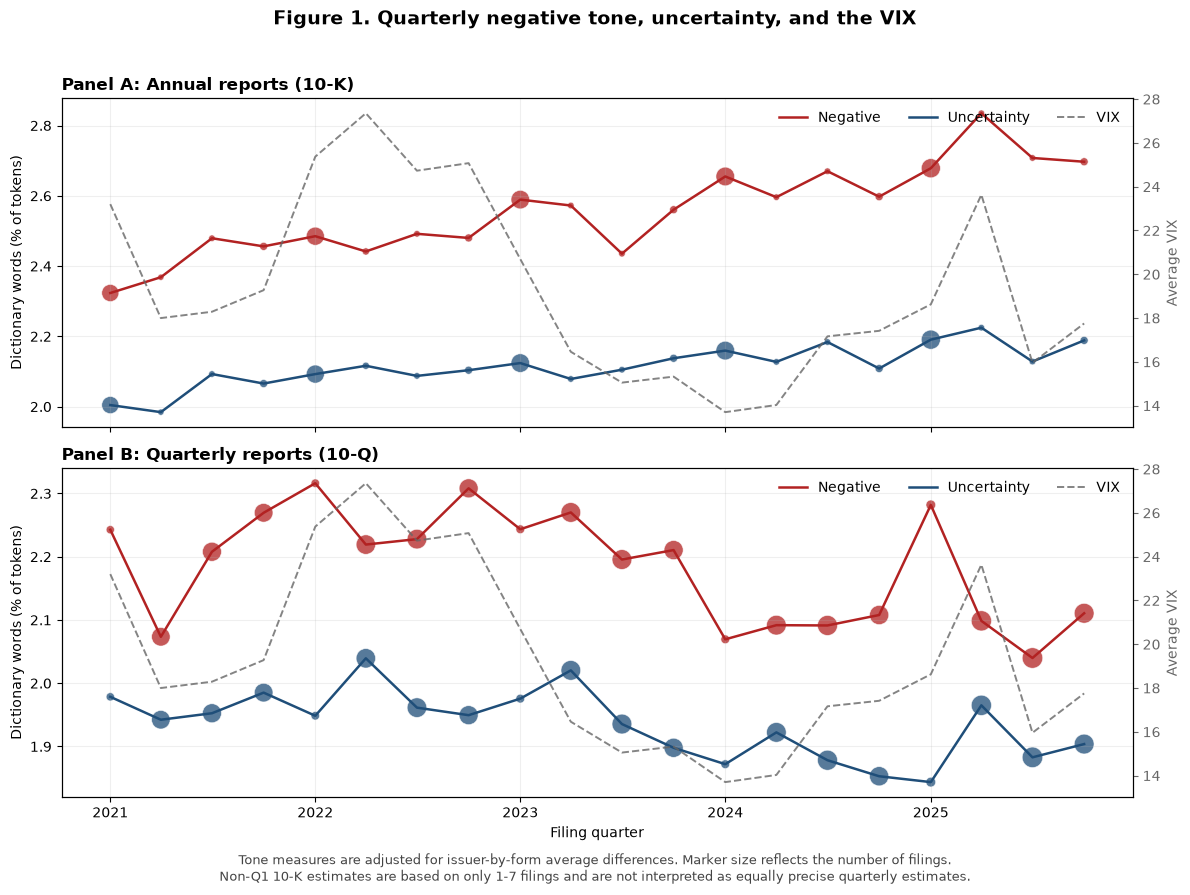

Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\figure1_quarterly_tone_vix.png


In [30]:
# generating figure 1

plot_data = quarterly_tone.copy()

plot_data["quarter_date"] = (
    plot_data["filing_quarter"]
    .dt.to_timestamp(how="start")
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 9),
    sharex=True
)

form_titles = {
    "10-K": "Panel A: Annual reports (10-K)",
    "10-Q": "Panel B: Quarterly reports (10-Q)",
}

for ax, form in zip(axes, ["10-K", "10-Q"]):
    form_data = (
        plot_data.loc[plot_data["form"] == form]
        .sort_values("quarter_date")
    )

    marker_sizes = (
        18
        + 2.2 * form_data["n_filings"]
    )

    # Composition-adjusted proportional scores
    ax.plot(
        form_data["quarter_date"],
        100 * form_data["negative_prop_adjusted"],
        color="#B22222",
        linewidth=1.8,
        label="Negative"
    )

    ax.scatter(
        form_data["quarter_date"],
        100 * form_data["negative_prop_adjusted"],
        s=marker_sizes,
        color="#B22222",
        alpha=0.75,
        edgecolor="white",
        linewidth=0.5
    )

    ax.plot(
        form_data["quarter_date"],
        100 * form_data["uncertainty_prop_adjusted"],
        color="#1F4E79",
        linewidth=1.8,
        label="Uncertainty"
    )

    ax.scatter(
        form_data["quarter_date"],
        100 * form_data["uncertainty_prop_adjusted"],
        s=marker_sizes,
        color="#1F4E79",
        alpha=0.75,
        edgecolor="white",
        linewidth=0.5
    )

    ax.set_title(
        form_titles[form],
        loc="left",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Dictionary words (% of tokens)"
    )

    ax.grid(
        axis="both",
        alpha=0.2
    )

    # VIX comparison on secondary axis
    vix_axis = ax.twinx()

    vix_axis.plot(
        form_data["quarter_date"],
        form_data["vix"],
        color="#666666",
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label="VIX"
    )

    vix_axis.set_ylabel(
        "Average VIX",
        color="#666666"
    )

    vix_axis.tick_params(
        axis="y",
        colors="#666666"
    )

    # Combine legends from both axes
    handles_1, labels_1 = ax.get_legend_handles_labels()
    handles_2, labels_2 = vix_axis.get_legend_handles_labels()

    ax.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="upper right",
        frameon=False,
        ncol=3
    )

axes[-1].set_xlabel("Filing quarter")

fig.suptitle(
    "Figure 1. Quarterly negative tone, uncertainty, and the VIX",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.012,
    "Tone measures are adjusted for issuer-by-form average differences. "
    "Marker size reflects the number of filings.\n"
    "Non-Q1 10-K estimates are based on only 1-7 filings and are not "
    "interpreted as equally precise quarterly estimates.",
    ha="center",
    fontsize=9,
    color="#444444"
)

fig.tight_layout(
    rect=[0, 0.04, 1, 0.96]
)

figure1_path = (
    ROOT / "outputs/figure1_quarterly_tone_vix.png"
)

fig.savefig(
    figure1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure1_path)

## 8. Trend tests

I first regress each composition-adjusted quarterly measure on a linear time
trend. The slope is expressed as the annual change in the measure. Because the
aggregate regressions contain only 20 persistent quarterly observations, I
report both conventional OLS and Newey-West t-statistics. The Newey-West
covariance estimator uses four quarterly lags.

These aggregate tests remain sensitive to the small number of non-Q1 10-Ks.
The within-firm tests reported next are therefore treated as the primary trend
evidence.

In [31]:
# time variables

quarterly_tone["time_years"] = (
    quarterly_tone["filing_quarter"].astype(int)
    - pd.Period("2021Q1", freq="Q").ordinal
) / 4.0

assert quarterly_tone.groupby("form").size().eq(20).all()

display(
    quarterly_tone[
        [
            "filing_quarter",
            "form",
            "n_filings",
            "time_years",
        ]
    ].head()
)

,filing_quarter,form,n_filings,time_years
0,2021Q1,10-K,61,0.00
1,2021Q1,10-Q,8,0.00
2,2021Q2,10-K,1,0.25
3,2021Q2,10-Q,73,0.25
4,2021Q3,10-K,2,0.50


In [32]:
# aggregate OLS and Newey-West

aggregate_trend_specs = {
    "Negative proportion (%)": (
        "negative_prop_adjusted",
        100.0
    ),
    "Uncertainty proportion (%)": (
        "uncertainty_prop_adjusted",
        100.0
    ),
    "Negative tf-idf": (
        "negative_tfidf_adjusted",
        1.0
    ),
    "Uncertainty tf-idf": (
        "uncertainty_tfidf_adjusted",
        1.0
    ),
}

aggregate_trend_rows = []

for form in ["10-K", "10-Q"]:
    form_quarters = (
        quarterly_tone.loc[
            quarterly_tone["form"] == form
        ]
        .sort_values("filing_quarter")
    )

    X = sm.add_constant(
        form_quarters["time_years"]
    )

    for measure_label, (
        variable_name,
        display_scale
    ) in aggregate_trend_specs.items():

        y = (
            form_quarters[variable_name]
            * display_scale
        )

        conventional_model = sm.OLS(
            y,
            X
        ).fit()

        newey_west_model = sm.OLS(
            y,
            X
        ).fit(
            cov_type="HAC",
            cov_kwds={
                "maxlags": 4,
                "use_correction": True,
            }
        )

        aggregate_trend_rows.append({
            "Form": form,
            "Measure": measure_label,
            "Quarter observations": len(form_quarters),
            "Slope per year":
                conventional_model.params["time_years"],
            "OLS t-stat":
                conventional_model.tvalues["time_years"],
            "OLS p-value":
                conventional_model.pvalues["time_years"],
            "Newey-West t-stat":
                newey_west_model.tvalues["time_years"],
            "Newey-West p-value":
                newey_west_model.pvalues["time_years"],
        })

aggregate_trends = (
    pd.DataFrame(aggregate_trend_rows)
    .set_index(["Form", "Measure"])
)

print("Table 4, Panel A. Aggregate quarterly trend tests")
display(aggregate_trends.round(4))

Table 4, Panel A. Aggregate quarterly trend tests


Quarter observations  Slope per year  OLS t-stat  OLS p-value  Newey-West t-stat  Newey-West p-value
Form Measure                                                                                                                         
10-K Negative proportion (%)                       20          0.0775      8.5560       0.0000            14.5102              0.0000
     Uncertainty proportion (%)                    20          0.0329      6.2582       0.0000             7.0521              0.0000
     Negative tf-idf                               20          1.2550      4.3179       0.0004             4.7583              0.0000
     Uncertainty tf-idf                            20         -0.0946     -2.3713       0.0291            -3.1436              0.0017
10-Q Negative proportion (%)                       20         -0.0310     -2.5547       0.0199            -2.6628              0.0077
     Uncertainty proportion (%)                    20         -0.0227     -3.4462       0.0029            -3.9799              0.0001
     Negative tf-idf                               20         -0.4920     -3.3327       0.0037            -4.2963              0.0000
     Uncertainty tf-idf                            20         -0.1528     -8.1410       0.0000            -9.7604              0.0000

### Within-firm trend tests

The primary trend specification uses filing-level observations and issuer fixed
effects. The coefficient is therefore identified by changes in tone within the
same issuer rather than by changes in the firms represented in the sample.

Standard errors are clustered by both issuer and filing quarter. Issuer
clustering allows observations from the same company to remain correlated over
time, while filing-quarter clustering allows companies filing in the same
quarter to share common shocks. Issuers with only one observation for a given
form are excluded because they contain no within-issuer time variation.

In [33]:
# imports and filing-level time

import statsmodels.formula.api as smf

from scipy import stats
from statsmodels.stats.sandwich_covariance import (
    cov_cluster_2groups
)

tone_scores["time_years"] = (
    tone_scores["filing_quarter"].astype(int)
    - pd.Period("2021Q1", freq="Q").ordinal
) / 4.0

In [34]:
# Within-firm fixed-effects trend regressions

within_firm_specs = {
    "Negative proportion (%)": (
        "negative_prop",
        100.0
    ),
    "Uncertainty proportion (%)": (
        "uncertainty_prop",
        100.0
    ),
    "Negative tf-idf": (
        "negative_tfidf",
        1.0
    ),
    "Uncertainty tf-idf": (
        "uncertainty_tfidf",
        1.0
    ),
}

within_firm_rows = []

for form in ["10-K", "10-Q"]:
    form_sample = tone_scores.loc[
        tone_scores["form"] == form
    ].copy()

    # A firm needs at least two filings of the same form
    # to contribute to a within-firm trend estimate.
    observations_per_firm = (
        form_sample
        .groupby("firm_id")
        .size()
    )

    eligible_firms = observations_per_firm.loc[
        observations_per_firm >= 2
    ].index

    form_sample = form_sample.loc[
        form_sample["firm_id"].isin(eligible_firms)
    ].copy()

    # Create a filing-quarter label for the second clustering dimension.
    form_sample["quarter_cluster"] = (
        form_sample["filing_quarter"]
        .astype(str)
    )

    for measure_label, (
        variable_name,
        display_scale
    ) in within_firm_specs.items():

        model_data = form_sample[
            [
                "firm_id",
                "quarter_cluster",
                "time_years",
                variable_name,
            ]
        ].dropna().copy()

        # Proportional measures are reported in percentage points.
        # TF-IDF measures remain in their original units.
        model_data["tone_value"] = (
            model_data[variable_name]
            * display_scale
        )

        # Filing-level regression with issuer fixed effects.
        fixed_effect_model = smf.ols(
            formula=(
                "tone_value ~ time_years "
                "+ C(firm_id)"
            ),
            data=model_data
        ).fit()

        # Convert string cluster labels to integer codes.
        # This avoids a statsmodels/NumPy compatibility error.
        firm_cluster_codes = pd.factorize(
            model_data["firm_id"]
        )[0].astype(np.int64)

        quarter_cluster_codes = pd.factorize(
            model_data["quarter_cluster"]
        )[0].astype(np.int64)

        # Two-way clustered covariance:
        # clustering dimension 1 = issuer
        # clustering dimension 2 = filing quarter
        covariance_both, _, _ = cov_cluster_2groups(
            fixed_effect_model,
            firm_cluster_codes,
            quarter_cluster_codes
        )

        coefficient_position = (
            fixed_effect_model
            .params
            .index
            .get_loc("time_years")
        )

        slope = fixed_effect_model.params[
            "time_years"
        ]

        slope_variance = covariance_both[
            coefficient_position,
            coefficient_position
        ]

        assert slope_variance > 0, (
            f"Nonpositive clustered variance for "
            f"{form}, {measure_label}"
        )

        clustered_standard_error = np.sqrt(
            slope_variance
        )

        clustered_t_stat = (
            slope /
            clustered_standard_error
        )

        # The quarter dimension has fewer clusters than the firm dimension,
        # so use its cluster count for conservative finite-sample inference.
        inference_df = (
            model_data["quarter_cluster"].nunique()
            - 1
        )

        clustered_p_value = (
            2.0
            * stats.t.sf(
                abs(clustered_t_stat),
                df=inference_df
            )
        )

        within_firm_rows.append({
            "Form": form,
            "Measure": measure_label,
            "Filing observations":
                len(model_data),
            "Issuers":
                model_data["firm_id"].nunique(),
            "Quarter clusters":
                model_data["quarter_cluster"].nunique(),
            "Slope per year":
                slope,
            "Two-way clustered SE":
                clustered_standard_error,
            "Clustered t-stat":
                clustered_t_stat,
            "Clustered p-value":
                clustered_p_value,
        })

within_firm_trends = (
    pd.DataFrame(within_firm_rows)
    .set_index(["Form", "Measure"])
)

print("Table 4, Panel B. Within-firm trend tests")

display(
    within_firm_trends.round(4)
)

Table 4, Panel B. Within-firm trend tests


Filing observations  Issuers  Quarter clusters  Slope per year  Two-way clustered SE  Clustered t-stat  \
Form Measure                                                                                                                              
10-K Negative proportion (%)                     407       85                20          0.0874                0.0154            5.6910   
     Uncertainty proportion (%)                  407       85                20          0.0426                0.0076            5.6430   
     Negative tf-idf                             407       85                20          0.9863                0.3776            2.6120   
     Uncertainty tf-idf                          407       85                20         -0.1102                0.0668           -1.6513   
10-Q Negative proportion (%)                    1271       92                20         -0.0353                0.0210           -1.6852   
     Uncertainty proportion (%)                 1271       92                20         -0.0221                0.0112           -1.9741   
     Negative tf-idf                            1271       92                20         -0.5529                0.3648           -1.5156   
     Uncertainty tf-idf                         1271       92                20         -0.1601                0.0454           -3.5239   

                                 Clustered p-value  
Form Measure                                        
10-K Negative proportion (%)                0.0000  
     Uncertainty proportion (%)             0.0000  
     Negative tf-idf                        0.0171  
     Uncertainty tf-idf                     0.1151  
10-Q Negative proportion (%)                0.1083  
     Uncertainty proportion (%)             0.0631  
     Negative tf-idf                        0.1461  
     Uncertainty tf-idf                     0.0023

In [35]:
# Combine aggregate and within-firm trend results into Table 4

aggregate_table4 = (
    aggregate_trends
    .reset_index()
    .rename(columns={
        "Slope per year": "Aggregate slope/year",
        "Newey-West t-stat": "Newey-West t",
        "Newey-West p-value": "Newey-West p",
    })
)

within_table4 = (
    within_firm_trends
    .reset_index()
    .rename(columns={
        "Slope per year": "Within-firm slope/year",
        "Clustered t-stat": "Clustered t",
        "Clustered p-value": "Clustered p",
    })
)

table4 = aggregate_table4.merge(
    within_table4,
    on=["Form", "Measure"],
    how="inner",
    validate="one_to_one"
)

table4 = table4[
    [
        "Form",
        "Measure",
        "Quarter observations",
        "Aggregate slope/year",
        "Newey-West t",
        "Newey-West p",
        "Filing observations",
        "Issuers",
        "Within-firm slope/year",
        "Clustered t",
        "Clustered p",
    ]
]

table4 = table4.set_index(
    ["Form", "Measure"]
)

assert len(table4) == 8

print("Table 4. Aggregate and within-firm trend tests")

display(
    table4.round(4)
)

Table 4. Aggregate and within-firm trend tests


Quarter observations  Aggregate slope/year  Newey-West t  Newey-West p  Filing observations  Issuers  \
Form Measure                                                                                                                            
10-K Negative proportion (%)                       20                0.0775       14.5102        0.0000                  407       85   
     Uncertainty proportion (%)                    20                0.0329        7.0521        0.0000                  407       85   
     Negative tf-idf                               20                1.2550        4.7583        0.0000                  407       85   
     Uncertainty tf-idf                            20               -0.0946       -3.1436        0.0017                  407       85   
10-Q Negative proportion (%)                       20               -0.0310       -2.6628        0.0077                 1271       92   
     Uncertainty proportion (%)                    20               -0.0227       -3.9799        0.0001                 1271       92   
     Negative tf-idf                               20               -0.4920       -4.2963        0.0000                 1271       92   
     Uncertainty tf-idf                            20               -0.1528       -9.7604        0.0000                 1271       92   

                                 Within-firm slope/year  Clustered t  Clustered p  
Form Measure                                                                       
10-K Negative proportion (%)                     0.0874       5.6910       0.0000  
     Uncertainty proportion (%)                  0.0426       5.6430       0.0000  
     Negative tf-idf                             0.9863       2.6120       0.0171  
     Uncertainty tf-idf                         -0.1102      -1.6513       0.1151  
10-Q Negative proportion (%)                    -0.0353      -1.6852       0.1083  
     Uncertainty proportion (%)                 -0.0221      -1.9741       0.0631  
     Negative tf-idf                            -0.5529      -1.5156       0.1461  
     Uncertainty tf-idf                         -0.1601      -3.5239       0.0023

### Interpretation of the trend tests

The within-firm estimates provide the primary evidence. Negative tone in 10-Ks
increased over the sample period. The proportional score rose by approximately
0.087 percentage points per year, and the tf-idf result was also positive and
statistically significant.

The 10-K uncertainty result depends on weighting. The proportional measure
increased significantly, but the tf-idf slope was negative and statistically
insignificant. This suggests that the increase was concentrated in common
uncertainty language rather than in less ubiquitous, more document-specific
terms.

For 10-Qs, the significant negative aggregate trends in Negative tone disappear
in the within-firm specifications. The aggregate result therefore appears to be
sensitive to the changing composition of filing firms. In contrast, the
within-firm decline in tf-idf Uncertainty remains statistically significant,
although the proportional result is only marginal at conventional levels.

Overall, the evidence does not support one common trend across both filing
forms. Annual reports became more negative, whereas quarterly-report Negative
tone did not change reliably within firms. Distinctive uncertainty language
declined in 10-Qs but showed no reliable trend in 10-Ks.

## 9. Filing event dates and market variables

### Tradable filing day

The SEC acceptance timestamp, rather than the reported filing date alone,
determines when investors could trade on the filing. I convert each timestamp
from UTC to US Eastern time. A filing accepted before 4:00 PM Eastern on a
trading day is assigned that date as day 0. A filing accepted at or after the
market close, or on a nontrading day, is assigned the next trading day.

The trading calendar is defined by dates on which SPY has a valid price in the
downloaded market dataset.

In [36]:
# prepare the trading calendar

# SPY trading dates define the US equity trading calendar.

trading_days = pd.DatetimeIndex(
    prices.index[prices["SPY"].notna()]
)

# Remove any timezone information and time-of-day component.
trading_days = (
    trading_days
    .tz_localize(None)
    .normalize()
    .sort_values()
    .unique()
)

assert trading_days.is_monotonic_increasing
assert trading_days.is_unique

print("Trading calendar begins:", trading_days.min())
print("Trading calendar ends:", trading_days.max())
print("Number of trading days:", len(trading_days))

Trading calendar begins: 2020-09-01 00:00:00
Trading calendar ends: 2026-03-30 00:00:00
Number of trading days: 1400


In [37]:
# convert acceptance timestamps

tone_scores["acceptance_eastern"] = (
    tone_scores["acceptance_datetime"]
    .dt.tz_convert("America/New_York")
)

tone_scores["acceptance_local_date"] = (
    tone_scores["acceptance_eastern"]
    .dt.tz_localize(None)
    .dt.normalize()
)

tone_scores["acceptance_minutes"] = (
    tone_scores["acceptance_eastern"].dt.hour * 60
    + tone_scores["acceptance_eastern"].dt.minute
    + tone_scores["acceptance_eastern"].dt.second / 60
)

market_close_minutes = 16 * 60

tone_scores["accepted_on_trading_date"] = (
    tone_scores["acceptance_local_date"]
    .isin(trading_days)
)

tone_scores["accepted_after_close"] = (
    tone_scores["accepted_on_trading_date"]
    & (
        tone_scores["acceptance_minutes"]
        >= market_close_minutes
    )
)

tone_scores["accepted_on_nontrading_date"] = (
    ~tone_scores["accepted_on_trading_date"]
)

In [38]:
# assign day 0

def assign_tradable_day(
    local_date,
    acceptance_minutes,
    trading_calendar
):
    """
    Return the first trading day on which the filing could be traded.
    """

    calendar_position = trading_calendar.searchsorted(
        local_date,
        side="left"
    )

    if calendar_position >= len(trading_calendar):
        return pd.NaT

    candidate_date = trading_calendar[calendar_position]

    accepted_before_close = (
        candidate_date == local_date
        and acceptance_minutes < market_close_minutes
    )

    if accepted_before_close:
        return candidate_date

    # If candidate_date is the filing date but the filing arrived after
    # the close, advance to the next trading date.
    if candidate_date == local_date:
        calendar_position += 1

    if calendar_position >= len(trading_calendar):
        return pd.NaT

    return trading_calendar[calendar_position]


tone_scores["day0"] = [
    assign_tradable_day(
        local_date,
        acceptance_minutes,
        trading_days
    )
    for local_date, acceptance_minutes in zip(
        tone_scores["acceptance_local_date"],
        tone_scores["acceptance_minutes"]
    )
]

tone_scores["day0"] = pd.to_datetime(
    tone_scores["day0"]
)

assert tone_scores["day0"].notna().all()
assert tone_scores["day0"].isin(trading_days).all()
assert (
    tone_scores["day0"]
    >= tone_scores["acceptance_local_date"]
).all()

In [39]:
# classify and audit assignments

tone_scores["day0_reason"] = np.select(
    [
        tone_scores["accepted_on_nontrading_date"],
        tone_scores["accepted_after_close"],
    ],
    [
        "Next trading day: nontrading acceptance date",
        "Next trading day: accepted after market close",
    ],
    default="Same trading day: accepted before close"
)

tone_scores["day0_moved"] = (
    tone_scores["day0"]
    != tone_scores["acceptance_local_date"]
)

day0_summary = (
    tone_scores["day0_reason"]
    .value_counts()
    .rename_axis("Day-0 rule")
    .to_frame("Filings")
)

day0_summary["Percent"] = (
    100
    * day0_summary["Filings"]
    / len(tone_scores)
)

print("Day-0 assignment summary")
display(day0_summary.round(2))

print(
    "Total filings moved to a later trading day:",
    int(tone_scores["day0_moved"].sum())
)

print(
    "Day-0 range:",
    tone_scores["day0"].min(),
    "to",
    tone_scores["day0"].max()
)

Day-0 assignment summary


,Filings,Percent
Day-0 rule,,
Next trading day: accepted after market close,1263,75.09
Same trading day: accepted before close,416,24.73
Next trading day: nontrading acceptance date,3,0.18


Total filings moved to a later trading day: 1266
Day-0 range: 2021-01-28 00:00:00 to 2025-12-23 00:00:00


In [40]:
# inspect moved filings

moved_filing_examples = (
    tone_scores.loc[
        tone_scores["day0_moved"],
        [
            "ticker",
            "form",
            "acceptance_eastern",
            "acceptance_local_date",
            "day0",
            "day0_reason",
        ]
    ]
    .head(15)
)

display(moved_filing_examples)

,ticker,form,acceptance_eastern,acceptance_local_date,day0,day0_reason
accession,,,,,,
0000936468-21-000013,LMT,10-K,2021-01-28 17:08:55-05:00,2021-01-28,2021-01-29,Next trading day: accepted after market close
0001326801-21-000014,META,10-K,2021-01-27 21:13:48-05:00,2021-01-27,2021-01-28,Next trading day: accepted after market close
0001065280-21-000040,NFLX,10-K,2021-01-28 16:21:59-05:00,2021-01-28,2021-01-29,Next trading day: accepted after market close
0001628280-21-001185,AMD,10-K,2021-01-29 17:24:00-05:00,2021-01-29,2021-02-01,Next trading day: accepted after market close
0001018724-21-000004,AMZN,10-K,2021-02-02 19:44:10-05:00,2021-02-02,2021-02-03,Next trading day: accepted after market close
0001652044-21-000010,GOOGL,10-K,2021-02-02 20:12:25-05:00,2021-02-02,2021-02-03,Next trading day: accepted after market close
0001506293-21-000025,PINS,10-K,2021-02-04 17:57:32-05:00,2021-02-04,2021-02-05,Next trading day: accepted after market close
0001633917-21-000018,PYPL,10-K,2021-02-04 19:30:14-05:00,2021-02-04,2021-02-05,Next trading day: accepted after market close
0001193125-21-032669,TWST,10-Q,2021-02-08 18:58:14-05:00,2021-02-08,2021-02-09,Next trading day: accepted after market close


### Return and volatility windows

Daily returns are calculated from auto-adjusted closing prices without filling
missing observations. Filing-period excess return is the firm's four-day
buy-and-hold return minus the SPY buy-and-hold return over trading days
\([0,3]\).

Pre- and post-filing volatility are measured over trading days \([-60,-6]\) and
\([6,65]\), respectively. I use the annualized standard deviation of daily
market-adjusted returns, where the market adjustment subtracts the SPY return.
The event period and the following five trading days are excluded from both
volatility windows.

An event return requires all four daily returns. A volatility window requires at
least 50 of 55 pre-filing observations and at least 55 of 60 post-filing
observations. Missing prices are never forward-filled.

In [41]:
# calculate daily returns

# Align all price series to the SPY trading calendar.

aligned_prices = prices.reindex(trading_days)

daily_returns = aligned_prices.pct_change(
    fill_method=None
)

spy_returns = daily_returns["SPY"]

market_adjusted_returns = daily_returns.sub(
    spy_returns,
    axis=0
)

assert daily_returns.index.equals(trading_days)
assert market_adjusted_returns.index.equals(trading_days)

print("Daily-return matrix shape:", daily_returns.shape)

Daily-return matrix shape: (1400, 96)


In [42]:
# map each day 0 to a calendar position

trading_day_positions = pd.Series(
    np.arange(len(trading_days)),
    index=trading_days
)

tone_scores["day0_position"] = (
    tone_scores["day0"]
    .map(trading_day_positions)
)

assert tone_scores["day0_position"].notna().all()

tone_scores["day0_position"] = (
    tone_scores["day0_position"].astype(int)
)

In [43]:
# function for one filing

PRE_START = -60
PRE_END = -6

EVENT_START = 0
EVENT_END = 3

POST_START = 6
POST_END = 65

MIN_PRE_OBSERVATIONS = 50
MIN_POST_OBSERVATIONS = 55


def calculate_filing_market_variables(
    ticker,
    day0_position
):
    """
    Construct return and volatility variables for one filing.

    All window endpoints are inclusive.
    """

    stock_returns = daily_returns[ticker]
    stock_excess_returns = market_adjusted_returns[ticker]

    pre_slice = slice(
        day0_position + PRE_START,
        day0_position + PRE_END + 1
    )

    event_slice = slice(
        day0_position + EVENT_START,
        day0_position + EVENT_END + 1
    )

    post_slice = slice(
        day0_position + POST_START,
        day0_position + POST_END + 1
    )

    pre_excess = stock_excess_returns.iloc[
        pre_slice
    ]

    event_stock = stock_returns.iloc[
        event_slice
    ]

    event_spy = spy_returns.iloc[
        event_slice
    ]

    post_excess = stock_excess_returns.iloc[
        post_slice
    ]

    n_pre_returns = int(pre_excess.notna().sum())
    n_event_stock_returns = int(
        event_stock.notna().sum()
    )
    n_event_spy_returns = int(
        event_spy.notna().sum()
    )
    n_post_returns = int(post_excess.notna().sum())

    pre_volatility = np.nan

    if n_pre_returns >= MIN_PRE_OBSERVATIONS:
        pre_volatility = (
            pre_excess.std(ddof=1)
            * np.sqrt(252)
        )

    post_volatility = np.nan

    if n_post_returns >= MIN_POST_OBSERVATIONS:
        post_volatility = (
            post_excess.std(ddof=1)
            * np.sqrt(252)
        )

    event_excess_return = np.nan

    if (
        n_event_stock_returns == 4
        and n_event_spy_returns == 4
    ):
        stock_buy_and_hold_return = (
            (1.0 + event_stock).prod()
            - 1.0
        )

        spy_buy_and_hold_return = (
            (1.0 + event_spy).prod()
            - 1.0
        )

        event_excess_return = (
            stock_buy_and_hold_return
            - spy_buy_and_hold_return
        )

    return {
        "n_pre_returns": n_pre_returns,
        "n_event_returns": n_event_stock_returns,
        "n_post_returns": n_post_returns,
        "pre_volatility": pre_volatility,
        "post_volatility": post_volatility,
        "event_excess_return": event_excess_return,
    }

In [44]:
# calculate all filing-level windows

market_variable_rows = []

for accession, filing in tone_scores.iterrows():
    filing_variables = calculate_filing_market_variables(
        ticker=filing["ticker"],
        day0_position=filing["day0_position"]
    )

    filing_variables["accession"] = accession
    market_variable_rows.append(filing_variables)

filing_market_variables = (
    pd.DataFrame(market_variable_rows)
    .set_index("accession")
)

tone_scores = tone_scores.join(
    filing_market_variables,
    how="left",
    validate="one_to_one"
)

print(
    "Constructed market variables for",
    len(filing_market_variables),
    "filings"
)

Constructed market variables for 1682 filings


In [45]:
# audit market-windowavailbility

market_window_summary = pd.DataFrame({
    "Variable": [
        "Four-day event excess return",
        "Pre-filing volatility",
        "Post-filing volatility",
        "Both pre- and post-filing volatility",
    ],
    "Available": [
        tone_scores["event_excess_return"].notna().sum(),
        tone_scores["pre_volatility"].notna().sum(),
        tone_scores["post_volatility"].notna().sum(),
        tone_scores[
            ["pre_volatility", "post_volatility"]
        ].notna().all(axis=1).sum(),
    ],
})

market_window_summary["Missing"] = (
    len(tone_scores)
    - market_window_summary["Available"]
)

market_window_summary["Available (%)"] = (
    100
    * market_window_summary["Available"]
    / len(tone_scores)
)

display(
    market_window_summary.round(2)
)

,Variable,Available,Missing,Available (%)
0,Four-day event excess return,1654,28,98.34
1,Pre-filing volatility,1632,50,97.03
2,Post-filing volatility,1655,27,98.39
3,Both pre- and post-filing volatility,1632,50,97.03


In [46]:
# inspect missingness by ticker

missing_market_windows = (
    tone_scores
    .assign(
        missing_event=lambda x:
            x["event_excess_return"].isna(),

        missing_pre_vol=lambda x:
            x["pre_volatility"].isna(),

        missing_post_vol=lambda x:
            x["post_volatility"].isna(),
    )
    .groupby("ticker")[
        [
            "missing_event",
            "missing_pre_vol",
            "missing_post_vol",
        ]
    ]
    .sum()
)

missing_market_windows = (
    missing_market_windows.loc[
        missing_market_windows.sum(axis=1) > 0
    ]
    .sort_values(
        [
            "missing_event",
            "missing_pre_vol",
            "missing_post_vol",
        ],
        ascending=False
    )
)

display(missing_market_windows)

,missing_event,missing_pre_vol,missing_post_vol
ticker,,,
BMNR,17,18,17
KDK,10,11,10
LUNR,1,1,0
ABNB,0,1,0
ABSI,0,1,0
ACHR,0,1,0
AUR,0,1,0
COIN,0,1,0
CRCL,0,1,0


In [47]:
# combine point-in-time shares

# merge point-in-time shares outstanding

share_columns = [
    "accession",
    "shares_outstanding",
    "shares_as_of",
    "shares_tag",
]

shares_clean = shares[
    share_columns
].copy()

shares_clean["shares_outstanding"] = pd.to_numeric(
    shares_clean["shares_outstanding"],
    errors="coerce"
)

shares_clean["shares_as_of"] = pd.to_datetime(
    shares_clean["shares_as_of"],
    errors="coerce"
)

assert shares_clean["accession"].is_unique

# Keep tone_scores unchanged and create the regression dataset separately.
analysis_data = tone_scores.copy()

analysis_data = analysis_data.join(
    shares_clean.set_index("accession"),
    how="left",
    validate="one_to_one"
)

print(
    "Filings with point-in-time shares:",
    analysis_data["shares_outstanding"].notna().sum()
)

print(
    "Filings missing point-in-time shares:",
    analysis_data["shares_outstanding"].isna().sum()
)

print("Share-count sources")

display(
    analysis_data["shares_tag"]
    .value_counts(dropna=False)
    .rename_axis("XBRL share-count tag")
    .to_frame("Filings")
)

Filings with point-in-time shares: 1619
Filings missing point-in-time shares: 63
Share-count sources


,Filings
XBRL share-count tag,
dei:EntityCommonStockSharesOutstanding,1089
us-gaap:WeightedAverageNumberOfDilutedSharesOutstanding,504
NaN,63
us-gaap:CommonStockSharesOutstanding,22
us-gaap:WeightedAverageNumberOfSharesOutstandingBasic,4


In [48]:
# construct filing-level market controls

aligned_volume = volume.reindex(trading_days)

assert aligned_volume.index.equals(trading_days)


def calculate_filing_controls(
    ticker,
    day0_position,
    shares_outstanding
):
    """
    Construct controls for one filing.

    Market capitalization uses the closing price on trading day -1.
    Turnover and prior excess return use trading days [-60, -6].
    """

    stock_prices = aligned_prices[ticker]
    stock_returns = daily_returns[ticker]
    stock_volume = aligned_volume[ticker]

    pre_slice = slice(
        day0_position + PRE_START,
        day0_position + PRE_END + 1
    )

    # Day -1 closing price
    lagged_price = np.nan

    if day0_position >= 1:
        lagged_price = stock_prices.iloc[
            day0_position - 1
        ]

    # Pre-filing volume
    pre_volume = stock_volume.iloc[pre_slice]

    n_pre_volume = int(
        pre_volume.notna().sum()
    )

    average_daily_volume = np.nan

    if n_pre_volume >= MIN_PRE_OBSERVATIONS:
        average_daily_volume = pre_volume.mean()

    # Pre-filing buy-and-hold excess return
    pre_stock_returns = stock_returns.iloc[
        pre_slice
    ]

    pre_spy_returns = spy_returns.iloc[
        pre_slice
    ]

    valid_pre_returns = (
        pre_stock_returns.notna()
        & pre_spy_returns.notna()
    )

    n_pre_control_returns = int(
        valid_pre_returns.sum()
    )

    pre_excess_return = np.nan

    if n_pre_control_returns >= MIN_PRE_OBSERVATIONS:
        stock_buy_and_hold = (
            (
                1.0
                + pre_stock_returns.loc[
                    valid_pre_returns
                ]
            ).prod()
            - 1.0
        )

        spy_buy_and_hold = (
            (
                1.0
                + pre_spy_returns.loc[
                    valid_pre_returns
                ]
            ).prod()
            - 1.0
        )

        pre_excess_return = (
            stock_buy_and_hold
            - spy_buy_and_hold
        )

    # Point-in-time size and turnover
    market_cap = np.nan
    average_turnover = np.nan

    valid_share_count = (
        pd.notna(shares_outstanding)
        and shares_outstanding > 0
    )

    if valid_share_count:
        if pd.notna(lagged_price) and lagged_price > 0:
            market_cap = (
                lagged_price
                * shares_outstanding
            )

        if (
            pd.notna(average_daily_volume)
            and average_daily_volume > 0
        ):
            average_turnover = (
                average_daily_volume
                / shares_outstanding
            )

    return {
        "lagged_price": lagged_price,
        "n_pre_volume": n_pre_volume,
        "n_pre_control_returns":
            n_pre_control_returns,
        "average_daily_volume":
            average_daily_volume,
        "market_cap": market_cap,
        "average_turnover":
            average_turnover,
        "pre_excess_return":
            pre_excess_return,
    }

In [49]:
# calculate controls for all filings

control_rows = []

for accession, filing in analysis_data.iterrows():
    filing_controls = calculate_filing_controls(
        ticker=filing["ticker"],
        day0_position=filing["day0_position"],
        shares_outstanding=filing[
            "shares_outstanding"
        ],
    )

    filing_controls["accession"] = accession
    control_rows.append(filing_controls)

filing_controls = (
    pd.DataFrame(control_rows)
    .set_index("accession")
)

assert filing_controls.index.is_unique
assert len(filing_controls) == len(analysis_data)

analysis_data = analysis_data.join(
    filing_controls,
    how="left",
    validate="one_to_one"
)

# Regression-friendly transformations
analysis_data["log_market_cap"] = np.log(
    analysis_data["market_cap"] / 1_000_000
)

analysis_data["log_turnover"] = np.log(
    analysis_data["average_turnover"]
)

analysis_data["pre_excess_return_pct"] = (
    100.0
    * analysis_data["pre_excess_return"]
)

analysis_data["event_excess_return_pct"] = (
    100.0
    * analysis_data["event_excess_return"]
)

analysis_data["pre_volatility_pct"] = (
    100.0
    * analysis_data["pre_volatility"]
)

analysis_data["post_volatility_pct"] = (
    100.0
    * analysis_data["post_volatility"]
)

print(
    "Constructed controls for",
    len(filing_controls),
    "filings"
)

Constructed controls for 1682 filings


In [50]:
# audit control-variable availability

control_availability = pd.DataFrame({
    "Variable": [
        "Point-in-time shares",
        "Lagged price",
        "Market capitalization",
        "Average turnover",
        "Pre-filing excess return",
        "Pre-filing volatility",
        "Post-filing volatility",
        "Four-day event excess return",
    ],
    "Available": [
        analysis_data[
            "shares_outstanding"
        ].notna().sum(),

        analysis_data[
            "lagged_price"
        ].notna().sum(),

        analysis_data[
            "market_cap"
        ].notna().sum(),

        analysis_data[
            "average_turnover"
        ].notna().sum(),

        analysis_data[
            "pre_excess_return"
        ].notna().sum(),

        analysis_data[
            "pre_volatility"
        ].notna().sum(),

        analysis_data[
            "post_volatility"
        ].notna().sum(),

        analysis_data[
            "event_excess_return"
        ].notna().sum(),
    ],
})

control_availability["Missing"] = (
    len(analysis_data)
    - control_availability["Available"]
)

control_availability["Available (%)"] = (
    100.0
    * control_availability["Available"]
    / len(analysis_data)
)

display(
    control_availability.round(2)
)

print("Continuous-control distributions")

display(
    analysis_data[
        [
            "shares_outstanding",
            "market_cap",
            "average_turnover",
            "log_market_cap",
            "log_turnover",
            "pre_excess_return_pct",
            "event_excess_return_pct",
            "pre_volatility_pct",
            "post_volatility_pct",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
        ]
    )
    .T
    .round(4)
)

,Variable,Available,Missing,Available (%)
0,Point-in-time shares,1619,63,96.25
1,Lagged price,1654,28,98.34
2,Market capitalization,1601,81,95.18
3,Average turnover,1586,96,94.29
4,Pre-filing excess return,1632,50,97.03
5,Pre-filing volatility,1632,50,97.03
6,Post-filing volatility,1655,27,98.39
7,Four-day event excess return,1654,28,98.34


Continuous-control distributions


,count,mean,std,min,1%,5%,50%,95%,99%,max
shares_outstanding,1619.0,6.932383e+08,2.137481e+09,8.232500e+04,2.481176e+07,3.481123e+07,1.931250e+08,2.491000e+09,1.236480e+10,2.453000e+10
market_cap,1601.0,1.066100e+11,3.715175e+11,3.346511e+06,1.103592e+08,3.046953e+08,1.323822e+10,4.560655e+11,1.948528e+12,4.526663e+12
average_turnover,1586.0,1.985000e-01,3.499200e+00,1.000000e-04,2.000000e-03,3.500000e-03,1.080000e-02,6.920000e-02,2.061000e-01,7.654080e+01
log_market_cap,1601.0,9.336100e+00,2.214800e+00,1.207900e+00,4.703700e+00,5.719300e+00,9.490900e+00,1.303040e+01,1.448260e+01,1.532550e+01
log_turnover,1586.0,-4.407300e+00,1.052600e+00,-9.504300e+00,-6.211000e+00,-5.646600e+00,-4.525500e+00,-2.670400e+00,-1.579600e+00,4.337800e+00
pre_excess_return_pct,1632.0,1.143600e+00,2.765090e+01,-7.358650e+01,-4.708900e+01,-3.594860e+01,-1.904100e+00,4.977490e+01,9.845350e+01,2.680449e+02
event_excess_return_pct,1654.0,-3.030000e-01,1.166290e+01,-4.884970e+01,-2.794600e+01,-1.796830e+01,-8.114000e-01,1.929570e+01,3.674770e+01,7.848610e+01
pre_volatility_pct,1632.0,5.036830e+01,3.643700e+01,9.389000e+00,1.174610e+01,1.562710e+01,4.403640e+01,1.011999e+02,1.352223e+02,6.486129e+02
post_volatility_pct,1655.0,5.133520e+01,3.102720e+01,1.058340e+01,1.278420e+01,1.715310e+01,4.643800e+01,9.990420e+01,1.381158e+02,5.221342e+02


In [52]:
# download stock-split events

import yfinance as yf

market_tickers = sorted(
    analysis_data["ticker"].unique()
)

split_download = yf.download(
    tickers=market_tickers,
    start="2020-09-01",
    end="2026-09-12",
    auto_adjust=False,
    actions=True,
    progress=False,
    threads=True,
)

if isinstance(
    split_download.columns,
    pd.MultiIndex
):
    split_matrix = split_download[
        "Stock Splits"
    ].copy()
else:
    raise ValueError(
        "Unexpected yfinance column structure."
    )

split_events = (
    split_matrix
    .replace(0, np.nan)
    .stack()
    .rename("split_ratio")
    .reset_index()
)

split_events.columns = [
    "split_date",
    "ticker",
    "split_ratio",
]

split_events["split_date"] = (
    pd.to_datetime(
        split_events["split_date"]
    )
    .dt.tz_localize(None)
    .dt.normalize()
)

split_events = (
    split_events
    .loc[
        split_events["split_ratio"] > 0
    ]
    .sort_values(
        ["ticker", "split_date"]
    )
    .reset_index(drop=True)
)

print(
    "Stock-split events found:",
    len(split_events)
)

display(split_events)

Stock-split events found: 14


,split_date,ticker,split_ratio
0,2022-06-06,AMZN,20.000000
1,2024-07-15,AVGO,10.000000
2,2026-07-02,CRWD,4.000000
3,2022-07-18,GOOGL,20.000000
4,2025-10-30,HON,1.061000
5,2026-06-29,HON,0.953500
6,2024-06-25,ILMN,1.028000
7,2021-10-05,ISRG,3.000000
8,2025-11-17,NFLX,10.000000
9,2021-07-20,NVDA,4.000000


In [58]:
# correct share units and align shares with adjusted prices

analysis_data["shares_for_controls"] = (
    analysis_data["shares_outstanding"]
    .copy()
)

# Tempus reports its weighted-average share figures in thousands.
# The XBRL fallback values therefore need to be multiplied by 1,000.
tem_share_unit_fix = (
    analysis_data["ticker"].eq("TEM")
    & analysis_data["shares_tag"]
        .fillna("")
        .str.contains(
            "WeightedAverageNumberOf",
            regex=False
        )
    & (
        analysis_data[
            "shares_for_controls"
        ] < 1_000_000
    )
)

analysis_data.loc[
    tem_share_unit_fix,
    "shares_for_controls"
] *= 1_000

print(
    "TEM share observations corrected:",
    int(tem_share_unit_fix.sum())
)


def future_split_factor(
    ticker,
    reference_date
):
    """
    Return the cumulative split factor after the share-count date.

    Auto-adjusted historical price and volume use the latest split basis,
    so historical filing shares must be placed on the same basis.
    """

    if pd.isna(reference_date):
        return 1.0

    ticker_splits = split_events.loc[
        (
            split_events["ticker"] == ticker
        )
        & (
            split_events["split_date"]
            > reference_date
        ),
        "split_ratio",
    ]

    if ticker_splits.empty:
        return 1.0

    return float(ticker_splits.prod())


# Weighted-average share figures may already reflect stock splits
# occurring before the filing was published. Point-in-time share
# facts instead use their actual measurement date.

# Financial-statement share facts may already be retrospectively
# adjusted for splits occurring before the filing was published.
# Cover-page DEI shares instead use their actual measurement date.

financial_statement_share_fact = (
    analysis_data["shares_tag"]
    .fillna("")
    .str.startswith("us-gaap:")
)

analysis_data["share_reference_date"] = (
    analysis_data["shares_as_of"]
    .fillna(
        analysis_data["filing_date"]
    )
)

analysis_data.loc[
    financial_statement_share_fact,
    "share_reference_date"
] = analysis_data.loc[
    financial_statement_share_fact,
    "filing_date"
]

analysis_data["future_split_factor"] = [
    future_split_factor(
        ticker=ticker,
        reference_date=reference_date,
    )
    for ticker, reference_date in zip(
        analysis_data["ticker"],
        analysis_data["share_reference_date"],
    )
]

analysis_data["split_adjusted_shares"] = (
    analysis_data["shares_for_controls"]
    * analysis_data["future_split_factor"]
)

analysis_data["market_cap_for_controls"] = (
    analysis_data["lagged_price"]
    * analysis_data["split_adjusted_shares"]
)

analysis_data["turnover_for_controls"] = (
    analysis_data["average_daily_volume"]
    / analysis_data["split_adjusted_shares"]
)

analysis_data["log_market_cap"] = np.log(
    analysis_data[
        "market_cap_for_controls"
    ]
    / 1_000_000
)

analysis_data["log_turnover"] = np.log(
    analysis_data[
        "turnover_for_controls"
    ]
)

# Confirm that positive controls remain positive.
assert (
    analysis_data[
        "market_cap_for_controls"
    ]
    .dropna()
    .gt(0)
    .all()
)

assert (
    analysis_data[
        "turnover_for_controls"
    ]
    .dropna()
    .gt(0)
    .all()
)

print("Largest corrected turnover observations")

display(
    analysis_data[
        [
            "ticker",
            "form",
            "filing_date",
            "shares_outstanding",
            "shares_for_controls",
            "future_split_factor",
            "split_adjusted_shares",
            "market_cap_for_controls",
            "turnover_for_controls",
        ]
    ]
    .nlargest(
        20,
        "turnover_for_controls"
    )
    .round(4)
)

print("Corrected control distributions")

display(
    analysis_data[
        [
            "market_cap_for_controls",
            "turnover_for_controls",
            "log_market_cap",
            "log_turnover",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
        ]
    )
    .T
    .round(4)
)
print("Largest corrected market-cap observations")

display(
    analysis_data[
        [
            "ticker",
            "form",
            "filing_date",
            "shares_tag",
            "shares_outstanding",
            "future_split_factor",
            "split_adjusted_shares",
            "lagged_price",
            "market_cap_for_controls",
            "turnover_for_controls",
        ]
    ]
    .nlargest(
        15,
        "market_cap_for_controls"
    )
    .round(4)
)

TEM share observations corrected: 6
Largest corrected turnover observations


C:\Users\fangyi\AppData\Local\Temp\ipykernel_8724\736230197.py:174: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


,ticker,form,filing_date,shares_outstanding,shares_for_controls,future_split_factor,split_adjusted_shares,market_cap_for_controls,turnover_for_controls
accession,,,,,,,,,
0001844452-24-000036,LUNR,10-K,2024-03-25,25564313.0,25564313.0,1.0000,2.556431e+07,1.572205e+08,0.3872
0001844452-24-000070,LUNR,10-Q,2024-05-14,36612270.0,36612270.0,1.0000,3.661227e+07,2.222365e+08,0.2816
0001844452-25-000023,LUNR,10-K,2025-03-25,61410250.0,61410250.0,1.0000,6.141025e+07,5.649743e+08,0.2559
0001844452-24-000132,LUNR,10-Q,2024-11-15,67072014.0,67072014.0,1.0000,6.707201e+07,6.861467e+08,0.2501
0001816431-25-000014,QSI,10-K,2025-03-03,143196000.0,143196000.0,1.0000,1.431960e+08,1.861548e+08,0.2129
0001818331-23-000043,WGS,10-Q,2023-05-09,25590133.0,25590133.0,0.0303,7.754586e+05,6.475079e+06,0.1597
0001628280-25-039571,OKLO,10-Q,2025-08-11,147609194.0,147609194.0,1.0000,1.476092e+08,1.060720e+10,0.1507
0001628280-25-051349,OKLO,10-Q,2025-11-12,156247075.0,156247075.0,1.0000,1.562471e+08,1.628407e+10,0.1304
0001628280-25-014490,OKLO,10-K,2025-03-24,139018305.0,139018305.0,1.0000,1.390183e+08,4.297056e+09,0.1294


Corrected control distributions


,count,mean,std,min,1%,5%,50%,95%,99%,max
market_cap_for_controls,1601.0,1.335902e+11,4.089060e+11,6.475079e+06,1.241227e+08,3.175493e+08,1.384890e+10,8.042588e+11,1.959998e+12,4.526663e+12
turnover_for_controls,1586.0,1.560000e-02,2.160000e-02,4.000000e-04,2.100000e-03,3.500000e-03,1.030000e-02,4.450000e-02,9.060000e-02,3.872000e-01
log_market_cap,1601.0,9.463600e+00,2.299600e+00,1.868000e+00,4.821300e+00,5.760600e+00,9.536000e+00,1.359770e+01,1.448850e+01,1.532550e+01
log_turnover,1586.0,-4.531600e+00,7.862000e-01,-7.763500e+00,-6.180100e+00,-5.652400e+00,-4.579300e+00,-3.113200e+00,-2.400800e+00,-9.488000e-01


Largest corrected market-cap observations


C:\Users\fangyi\AppData\Local\Temp\ipykernel_8724\736230197.py:221: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(4)


,ticker,form,filing_date,shares_tag,shares_outstanding,future_split_factor,split_adjusted_shares,lagged_price,market_cap_for_controls,turnover_for_controls
accession,,,,,,,,,,
0001045810-25-000230,NVDA,10-Q,2025-11-19,dei:EntityCommonStockSharesOutstanding,2.430000e+10,1.0,2.430000e+10,186.2824,4.526663e+12,0.0077
0001045810-25-000209,NVDA,10-Q,2025-08-27,dei:EntityCommonStockSharesOutstanding,2.430000e+10,1.0,2.430000e+10,181.3585,4.407011e+12,0.0071
0001045810-24-000316,NVDA,10-Q,2024-11-20,dei:EntityCommonStockSharesOutstanding,2.449000e+10,1.0,2.449000e+10,145.6624,3.567272e+12,0.0111
0001652044-25-000091,GOOGL,10-Q,2025-10-30,us-gaap:WeightedAverageNumberOfDilutedSharesOu...,1.220300e+10,1.0,1.220300e+10,273.8578,3.341887e+12,0.0027
0001045810-25-000116,NVDA,10-Q,2025-05-28,dei:EntityCommonStockSharesOutstanding,2.440000e+10,1.0,2.440000e+10,134.6213,3.284761e+12,0.0115
0001045810-25-000023,NVDA,10-K,2025-02-26,dei:EntityCommonStockSharesOutstanding,2.440000e+10,1.0,2.440000e+10,131.0842,3.198455e+12,0.0098
0001045810-24-000264,NVDA,10-Q,2024-08-28,dei:EntityCommonStockSharesOutstanding,2.453000e+10,1.0,2.453000e+10,125.4033,3.076143e+12,0.0140
0001045810-24-000124,NVDA,10-Q,2024-05-29,dei:EntityCommonStockSharesOutstanding,2.460000e+09,10.0,2.460000e+10,114.6266,2.819815e+12,0.0197
0001652044-25-000014,GOOGL,10-K,2025-02-05,us-gaap:WeightedAverageNumberOfDilutedSharesOu...,1.244700e+10,1.0,1.244700e+10,205.1758,2.553823e+12,0.0022


### Table 5: Post-filing volatility and uncertainty

The dependent variable is annualized post-filing market-adjusted return
volatility over trading days [6, 65], expressed in percentage points.

The key explanatory variable is filing uncertainty, measured separately using
the proportional and tf-idf scores. Control variables are log market
capitalization, log pre-filing share turnover, pre-filing excess return, filing
form, and filing-quarter fixed effects.

Each specification is estimated twice on the same complete-case sample: first
without pre-filing volatility and then with annualized pre-filing volatility
over days [-60, -6]. Holding the sample constant ensures that the change in the
uncertainty coefficient is caused by adding the pre-volatility control rather
than by changing observations.

Standard errors are two-way clustered by issuer and filing quarter. Results are
also estimated separately for 10-K and 10-Q filings.

In [59]:
# prepare Table 5 regression sample

analysis_data["uncertainty_prop_pct"] = (
    100.0
    * analysis_data["uncertainty_prop"]
)

analysis_data["quarter_cluster"] = (
    analysis_data["filing_quarter"]
    .astype(str)
)

table5_required_variables = [
    "firm_id",
    "form",
    "quarter_cluster",
    "post_volatility_pct",
    "pre_volatility_pct",
    "uncertainty_prop_pct",
    "uncertainty_tfidf",
    "log_market_cap",
    "log_turnover",
    "pre_excess_return_pct",
]

table5_sample = (
    analysis_data[
        table5_required_variables
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .copy()
)

print(
    "Table 5 filing observations:",
    len(table5_sample)
)

print(
    "Table 5 issuers:",
    table5_sample["firm_id"].nunique()
)

print(
    "Table 5 quarter clusters:",
    table5_sample[
        "quarter_cluster"
    ].nunique()
)

display(
    pd.crosstab(
        table5_sample["form"],
        table5_sample["quarter_cluster"]
    )
)

Table 5 filing observations: 1586
Table 5 issuers: 91
Table 5 quarter clusters: 20


quarter_cluster,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4
form,,,,,,,,,,,,,,,,,,,,
10-K,46,1,2,6,67,4,2,6,72,2,2,6,72,2,2,6,77,2,2,7
10-Q,8,58,68,69,8,78,79,74,9,80,81,76,9,79,82,77,13,84,86,82


In [60]:
# helper for two-way clustered inference

def fit_two_way_clustered_regression(
    model_data,
    formula,
    coefficient_name
):
    """
    Fit OLS and calculate covariance clustered by issuer and quarter.
    """

    fitted_model = smf.ols(
        formula=formula,
        data=model_data
    ).fit()

    firm_codes = pd.factorize(
        model_data["firm_id"]
    )[0].astype(np.int64)

    quarter_codes = pd.factorize(
        model_data["quarter_cluster"]
    )[0].astype(np.int64)

    covariance_both, _, _ = cov_cluster_2groups(
        fitted_model,
        firm_codes,
        quarter_codes
    )

    coefficient_position = (
        fitted_model.params.index.get_loc(
            coefficient_name
        )
    )

    coefficient = fitted_model.params[
        coefficient_name
    ]

    coefficient_variance = covariance_both[
        coefficient_position,
        coefficient_position
    ]

    assert coefficient_variance > 0, (
        "Nonpositive clustered variance for "
        f"{coefficient_name}"
    )

    clustered_se = np.sqrt(
        coefficient_variance
    )

    clustered_t = (
        coefficient
        / clustered_se
    )

    number_of_firms = (
        model_data["firm_id"].nunique()
    )

    number_of_quarters = (
        model_data[
            "quarter_cluster"
        ].nunique()
    )

    inference_df = (
        min(
            number_of_firms,
            number_of_quarters
        )
        - 1
    )

    clustered_p = (
        2.0
        * stats.t.sf(
            abs(clustered_t),
            df=inference_df
        )
    )

    return {
        "Coefficient": coefficient,
        "Two-way clustered SE":
            clustered_se,
        "Clustered t-stat":
            clustered_t,
        "Clustered p-value":
            clustered_p,
        "Adjusted R-squared":
            fitted_model.rsquared_adj,
    }

In [61]:
# estimate Table 5 regressions

table5_uncertainty_measures = {
    "Proportional": "uncertainty_prop_pct",
    "TF-IDF": "uncertainty_tfidf",
}

table5_samples = {
    "All filings": table5_sample,
    "10-K": table5_sample.loc[
        table5_sample["form"] == "10-K"
    ].copy(),
    "10-Q": table5_sample.loc[
        table5_sample["form"] == "10-Q"
    ].copy(),
}

table5_rows = []

for sample_label, sample_data in table5_samples.items():

    for (
        weighting_label,
        uncertainty_variable
    ) in table5_uncertainty_measures.items():

        model_data = sample_data.copy()

        model_data["uncertainty_score"] = (
            model_data[
                uncertainty_variable
            ]
        )

        base_formula = (
            "post_volatility_pct "
            "~ uncertainty_score "
            "+ log_market_cap "
            "+ log_turnover "
            "+ pre_excess_return_pct "
            "+ C(quarter_cluster)"
        )

        if sample_label == "All filings":
            base_formula += " + C(form)"

        for include_pre_volatility in [
            False,
            True,
        ]:
            regression_formula = base_formula

            if include_pre_volatility:
                regression_formula += (
                    " + pre_volatility_pct"
                )

            regression_result = (
                fit_two_way_clustered_regression(
                    model_data=model_data,
                    formula=regression_formula,
                    coefficient_name=(
                        "uncertainty_score"
                    ),
                )
            )

            table5_rows.append({
                "Sample": sample_label,
                "Uncertainty measure":
                    weighting_label,
                "Pre-volatility control": (
                    "Yes"
                    if include_pre_volatility
                    else "No"
                ),
                "Observations":
                    len(model_data),
                "Issuers":
                    model_data[
                        "firm_id"
                    ].nunique(),
                "Quarter clusters":
                    model_data[
                        "quarter_cluster"
                    ].nunique(),
                **regression_result,
            })

table5 = (
    pd.DataFrame(table5_rows)
    .set_index(
        [
            "Sample",
            "Uncertainty measure",
            "Pre-volatility control",
        ]
    )
)

print(
    "Table 5. Post-filing volatility "
    "on uncertainty"
)

display(
    table5.round(4)
)

Table 5. Post-filing volatility on uncertainty


Observations  Issuers  Quarter clusters  Coefficient  Two-way clustered SE  \
Sample      Uncertainty measure Pre-volatility control                                                                               
All filings Proportional        No                              1586       91                20       5.9261                1.7939   
                                Yes                             1586       91                20       5.5041                1.4700   
            TF-IDF              No                              1586       91                20       1.1769                0.4036   
                                Yes                             1586       91                20       1.0913                0.3436   
10-K        Proportional        No                               386       88                20      18.8665                4.6071   
                                Yes                              386       88                20      18.8811                5.5259   
            TF-IDF              No                               386       88                20       1.5593                0.4254   
                                Yes                              386       88                20       1.5405                0.4191   
10-Q        Proportional        No                              1200       89                20       5.6498                1.8108   
                                Yes                             1200       89                20       5.1430                1.3620   
            TF-IDF              No                              1200       89                20       1.0760                0.4564   
                                Yes                             1200       89                20       0.9695                0.3736   

                                                        Clustered t-stat  Clustered p-value  Adjusted R-squared  
Sample      Uncertainty measure Pre-volatility control                                                           
All filings Proportional        No                                3.3035             0.0037              0.4782  
                                Yes                               3.7442             0.0014              0.5287  
            TF-IDF              No                                2.9157             0.0089              0.4762  
                                Yes                               3.1758             0.0050              0.5270  
10-K        Proportional        No                                4.0951             0.0006              0.5318  
                                Yes                               3.4168             0.0029              0.6074  
            TF-IDF              No                                3.6651             0.0016              0.5279  
                                Yes                               3.6756             0.0016              0.6028  
10-Q        Proportional        No                                3.1200             0.0056              0.4771  
                                Yes                               3.7762             0.0013              0.5207  
            TF-IDF              No                                2.3579             0.0293              0.4704  
                                Yes                               2.5952             0.0178              0.5150

### Table 6: Filing-period returns and negative sentiment

The dependent variable is the firm's four-day buy-and-hold return minus the SPY
buy-and-hold return over trading days [0, 3], expressed in percentage points.

The key explanatory variable is negative filing tone, measured separately using
the proportional and tf-idf scores. Controls include log market capitalization,
log pre-filing share turnover, pre-filing excess return, filing-form effects,
and filing-quarter fixed effects.

Standard errors are two-way clustered by issuer and filing quarter. Models are
estimated for the full filing sample and separately for 10-K and 10-Q filings.
The return regression is expected to have considerably lower statistical power
than the volatility regression because four-day returns contain substantial
firm-specific noise.

In [62]:
# prepare Table 6 regression sample

analysis_data["negative_prop_pct"] = (
    100.0
    * analysis_data["negative_prop"]
)

table6_required_variables = [
    "firm_id",
    "form",
    "quarter_cluster",
    "event_excess_return_pct",
    "negative_prop_pct",
    "negative_tfidf",
    "log_market_cap",
    "log_turnover",
    "pre_excess_return_pct",
]

table6_sample = (
    analysis_data[
        table6_required_variables
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .copy()
)

print(
    "Table 6 filing observations:",
    len(table6_sample)
)

print(
    "Table 6 issuers:",
    table6_sample["firm_id"].nunique()
)

print(
    "Table 6 quarter clusters:",
    table6_sample[
        "quarter_cluster"
    ].nunique()
)

display(
    table6_sample["form"]
    .value_counts()
    .rename_axis("Form")
    .to_frame("Filings")
)

Table 6 filing observations: 1586
Table 6 issuers: 91
Table 6 quarter clusters: 20


,Filings
Form,
10-Q,1200
10-K,386


In [63]:
# estimate Table 6 regressions

table6_sentiment_measures = {
    "Proportional": "negative_prop_pct",
    "TF-IDF": "negative_tfidf",
}

table6_samples = {
    "All filings": table6_sample,
    "10-K": table6_sample.loc[
        table6_sample["form"] == "10-K"
    ].copy(),
    "10-Q": table6_sample.loc[
        table6_sample["form"] == "10-Q"
    ].copy(),
}

table6_rows = []

for sample_label, sample_data in table6_samples.items():

    for (
        weighting_label,
        sentiment_variable
    ) in table6_sentiment_measures.items():

        model_data = sample_data.copy()

        model_data["negative_score"] = (
            model_data[sentiment_variable]
        )

        regression_formula = (
            "event_excess_return_pct "
            "~ negative_score "
            "+ log_market_cap "
            "+ log_turnover "
            "+ pre_excess_return_pct "
            "+ C(quarter_cluster)"
        )

        if sample_label == "All filings":
            regression_formula += " + C(form)"

        regression_result = (
            fit_two_way_clustered_regression(
                model_data=model_data,
                formula=regression_formula,
                coefficient_name="negative_score",
            )
        )

        tone_standard_deviation = (
            model_data["negative_score"]
            .std(ddof=1)
        )

        number_of_firms = (
            model_data["firm_id"].nunique()
        )

        number_of_quarters = (
            model_data[
                "quarter_cluster"
            ].nunique()
        )

        inference_df = (
            min(
                number_of_firms,
                number_of_quarters
            )
            - 1
        )

        # Approximate two-sided 5% test with 80% power.
        critical_value = stats.t.ppf(
            0.975,
            df=inference_df
        )

        power_value = stats.norm.ppf(0.80)

        minimum_detectable_coefficient = (
            (
                critical_value
                + power_value
            )
            * regression_result[
                "Two-way clustered SE"
            ]
        )

        table6_rows.append({
            "Sample": sample_label,
            "Sentiment measure":
                weighting_label,
            "Observations":
                len(model_data),
            "Issuers":
                number_of_firms,
            "Quarter clusters":
                number_of_quarters,
            **regression_result,
            "Tone-score SD":
                tone_standard_deviation,
            "Return effect of 1-SD tone":
                (
                    regression_result[
                        "Coefficient"
                    ]
                    * tone_standard_deviation
                ),
            "Approx. 80% MDE for 1-SD tone":
                (
                    minimum_detectable_coefficient
                    * tone_standard_deviation
                ),
        })

table6 = (
    pd.DataFrame(table6_rows)
    .set_index(
        [
            "Sample",
            "Sentiment measure",
        ]
    )
)

print(
    "Table 6. Filing-period return "
    "on negative sentiment"
)

display(
    table6.round(4)
)

Table 6. Filing-period return on negative sentiment


Observations  Issuers  Quarter clusters  Coefficient  Two-way clustered SE  Clustered t-stat  \
Sample      Sentiment measure                                                                                                 
All filings Proportional               1586       91                20      -0.5771                0.3264           -1.7682   
            TF-IDF                     1586       91                20      -0.0298                0.0176           -1.6918   
10-K        Proportional                386       88                20      -1.0749                0.9167           -1.1725   
            TF-IDF                      386       88                20      -0.0451                0.0451           -0.9999   
10-Q        Proportional               1200       89                20      -0.5977                0.3319           -1.8009   
            TF-IDF                     1200       89                20      -0.0254                0.0192           -1.3261   

                               Clustered p-value  Adjusted R-squared  Tone-score SD  Return effect of 1-SD tone  \
Sample      Sentiment measure                                                                                     
All filings Proportional                  0.0931              0.0098         0.9873                     -0.5698   
            TF-IDF                        0.1070              0.0106        25.0776                     -0.7481   
10-K        Proportional                  0.2555              0.0159         0.4413                     -0.4744   
            TF-IDF                        0.3299              0.0188        19.4499                     -0.8774   
10-Q        Proportional                  0.0876              0.0115         1.0905                     -0.6518   
            TF-IDF                        0.2005              0.0109        22.8574                     -0.5812   

                               Approx. 80% MDE for 1-SD tone  
Sample      Sentiment measure                                 
All filings Proportional                              0.9456  
            TF-IDF                                    1.2977  
10-K        Proportional                              1.1873  
            TF-IDF                                    2.5753  
10-Q        Proportional                              1.0621  
            TF-IDF                                    1.2861

In [64]:
# create report-ready Table 5

table5_flat = table5.reset_index()

table5_without_prevol = (
    table5_flat.loc[
        table5_flat[
            "Pre-volatility control"
        ] == "No",
        [
            "Sample",
            "Uncertainty measure",
            "Coefficient",
            "Clustered t-stat",
            "Clustered p-value",
            "Adjusted R-squared",
        ],
    ]
    .rename(
        columns={
            "Coefficient":
                "Coefficient without pre-vol",
            "Clustered t-stat":
                "t-stat without pre-vol",
            "Clustered p-value":
                "p-value without pre-vol",
            "Adjusted R-squared":
                "Adjusted R2 without pre-vol",
        }
    )
)

table5_with_prevol = (
    table5_flat.loc[
        table5_flat[
            "Pre-volatility control"
        ] == "Yes",
        [
            "Sample",
            "Uncertainty measure",
            "Observations",
            "Coefficient",
            "Clustered t-stat",
            "Clustered p-value",
            "Adjusted R-squared",
        ],
    ]
    .rename(
        columns={
            "Coefficient":
                "Coefficient with pre-vol",
            "Clustered t-stat":
                "t-stat with pre-vol",
            "Clustered p-value":
                "p-value with pre-vol",
            "Adjusted R-squared":
                "Adjusted R2 with pre-vol",
        }
    )
)

table5_tone_sd_rows = []

for sample_label, sample_data in table5_samples.items():
    for (
        measure_label,
        variable_name
    ) in table5_uncertainty_measures.items():

        table5_tone_sd_rows.append({
            "Sample": sample_label,
            "Uncertainty measure":
                measure_label,
            "Tone-score SD":
                sample_data[
                    variable_name
                ].std(ddof=1),
        })

table5_tone_sd = pd.DataFrame(
    table5_tone_sd_rows
)

table5_report = (
    table5_without_prevol
    .merge(
        table5_with_prevol,
        on=[
            "Sample",
            "Uncertainty measure",
        ],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        table5_tone_sd,
        on=[
            "Sample",
            "Uncertainty measure",
        ],
        how="left",
        validate="one_to_one",
    )
)

table5_report[
    "Coefficient change (%)"
] = (
    100.0
    * (
        table5_report[
            "Coefficient with pre-vol"
        ]
        - table5_report[
            "Coefficient without pre-vol"
        ]
    )
    / table5_report[
        "Coefficient without pre-vol"
    ].abs()
)

table5_report[
    "Post-volatility effect of 1-SD uncertainty"
] = (
    table5_report[
        "Coefficient with pre-vol"
    ]
    * table5_report["Tone-score SD"]
)

table5_report[
    "Adjusted R2 increase"
] = (
    table5_report[
        "Adjusted R2 with pre-vol"
    ]
    - table5_report[
        "Adjusted R2 without pre-vol"
    ]
)

table5_report = (
    table5_report[
        [
            "Sample",
            "Uncertainty measure",
            "Observations",
            "Coefficient without pre-vol",
            "t-stat without pre-vol",
            "Coefficient with pre-vol",
            "t-stat with pre-vol",
            "Coefficient change (%)",
            "Post-volatility effect of 1-SD uncertainty",
            "Adjusted R2 without pre-vol",
            "Adjusted R2 with pre-vol",
        ]
    ]
    .set_index(
        [
            "Sample",
            "Uncertainty measure",
        ]
    )
)

print(
    "Table 5. Post-filing volatility "
    "on uncertainty"
)

display(
    table5_report.round(4)
)

Table 5. Post-filing volatility on uncertainty


Observations  Coefficient without pre-vol  t-stat without pre-vol  Coefficient with pre-vol  \
Sample      Uncertainty measure                                                                                                
All filings Proportional                 1586                       5.9261                  3.3035                    5.5041   
            TF-IDF                       1586                       1.1769                  2.9157                    1.0913   
10-K        Proportional                  386                      18.8665                  4.0951                   18.8811   
            TF-IDF                        386                       1.5593                  3.6651                    1.5405   
10-Q        Proportional                 1200                       5.6498                  3.1200                    5.1430   
            TF-IDF                       1200                       1.0760                  2.3579                    0.9695   

                                 t-stat with pre-vol  Coefficient change (%)  Post-volatility effect of 1-SD uncertainty  \
Sample      Uncertainty measure                                                                                            
All filings Proportional                      3.7442                 -7.1205                                      3.2859   
            TF-IDF                            3.1758                 -7.2722                                      3.7246   
10-K        Proportional                      3.4168                  0.0777                                      4.9111   
            TF-IDF                            3.6756                 -1.2015                                      4.7327   
10-Q        Proportional                      3.7762                 -8.9703                                      3.4165   
            TF-IDF                            2.5952                 -9.9040                                      2.6311   

                                 Adjusted R2 without pre-vol  Adjusted R2 with pre-vol  
Sample      Uncertainty measure                                                         
All filings Proportional                              0.4782                    0.5287  
            TF-IDF                                    0.4762                    0.5270  
10-K        Proportional                              0.5318                    0.6074  
            TF-IDF                                    0.5279                    0.6028  
10-Q        Proportional                              0.4771                    0.5207  
            TF-IDF                                    0.4704                    0.5150

In [65]:
# Table 1 Panel C: regression-sample availability

number_with_shares = int(
    analysis_data[
        "shares_for_controls"
    ].notna().sum()
)

table1_panel_c = pd.DataFrame({
    "Analysis sample": [
        "Clean filing-text sample",
        "Filings with point-in-time share counts",
        "Table 5 volatility regression sample",
        "Table 6 filing-return regression sample",
    ],
    "Available filings": [
        len(analysis_data),
        number_with_shares,
        len(table5_sample),
        len(table6_sample),
    ],
    "Removed relative to prior relevant sample": [
        0,
        len(analysis_data) - number_with_shares,
        number_with_shares - len(table5_sample),
        number_with_shares - len(table6_sample),
    ],
})

table1_panel_c.index = np.arange(
    1,
    len(table1_panel_c) + 1
)

print(
    "Table 1, Panel C. "
    "Regression-sample availability"
)

display(table1_panel_c)

Table 1, Panel C. Regression-sample availability


,Analysis sample,Available filings,Removed relative to prior relevant sample
1,Clean filing-text sample,1682,0
2,Filings with point-in-time share counts,1619,63
3,Table 5 volatility regression sample,1586,33
4,Table 6 filing-return regression sample,1586,33


In [66]:
# create report-ready Table 6

table6_report = (
    table6
    .reset_index()
    [
        [
            "Sample",
            "Sentiment measure",
            "Observations",
            "Coefficient",
            "Clustered t-stat",
            "Clustered p-value",
            "Return effect of 1-SD tone",
            "Approx. 80% MDE for 1-SD tone",
            "Adjusted R-squared",
        ]
    ]
    .set_index(
        [
            "Sample",
            "Sentiment measure",
        ]
    )
)

print(
    "Table 6. Filing-period return "
    "on negative sentiment"
)

display(
    table6_report.round(4)
)

Table 6. Filing-period return on negative sentiment


Observations  Coefficient  Clustered t-stat  Clustered p-value  Return effect of 1-SD tone  \
Sample      Sentiment measure                                                                                               
All filings Proportional               1586      -0.5771           -1.7682             0.0931                     -0.5698   
            TF-IDF                     1586      -0.0298           -1.6918             0.1070                     -0.7481   
10-K        Proportional                386      -1.0749           -1.1725             0.2555                     -0.4744   
            TF-IDF                      386      -0.0451           -0.9999             0.3299                     -0.8774   
10-Q        Proportional               1200      -0.5977           -1.8009             0.0876                     -0.6518   
            TF-IDF                     1200      -0.0254           -1.3261             0.2005                     -0.5812   

                               Approx. 80% MDE for 1-SD tone  Adjusted R-squared  
Sample      Sentiment measure                                                     
All filings Proportional                              0.9456              0.0098  
            TF-IDF                                    1.2977              0.0106  
10-K        Proportional                              1.1873              0.0159  
            TF-IDF                                    2.5753              0.0188  
10-Q        Proportional                              1.0621              0.0115  
            TF-IDF                                    1.2861              0.0109

In [67]:
# export final tables and figures

OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

exhibit_files = {
    "table1_panel_a_company_sample.csv":
        table1_panel_a,

    "table1_panel_b_text_sample.csv":
        table1_panel_b_text,

    "table1_panel_c_regression_samples.csv":
        table1_panel_c,

    "table2_summary_statistics.csv":
        table2,

    "table3_top_dictionary_words.csv":
        table3,

    "table4_trend_tests.csv":
        table4,

    "table5_volatility_regressions.csv":
        table5_report,

    "table6_return_regressions.csv":
        table6_report,
}

for filename, exhibit in exhibit_files.items():
    output_path = OUTPUT_DIR / filename

    exhibit.to_csv(
        output_path,
        index=True
    )

    print(
        f"Saved: {output_path}"
    )

assert figure1_path.exists()

print(
    f"Saved: {figure1_path}"
)

print(
    "Total exported exhibits:",
    len(exhibit_files) + 1
)

Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table1_panel_a_company_sample.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table1_panel_b_text_sample.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table1_panel_c_regression_samples.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table2_summary_statistics.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table3_top_dictionary_words.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table4_trend_tests.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table5_volatility_regressions.csv
Saved: d:\School Work\FRE-GY 7871 NLP\Assignment 1\FRE-GY-7871A-Assignment1-main\outputs\table6_return_regressions.csv
Saved: d:\School Work\FRE-GY 7871 NL